# Set-up

In [1]:
import os
import sys
import yaml
import pickle
import glob
import pandas as pd
import scanpy as sc
import anndata as ad
from pycisTopic.cistopic_class import *
from pycisTopic.lda_models import *
from pycisTopic.clust_vis import *

import matplotlib.pyplot as plt
import seaborn as sns

The history saving thread hit an unexpected error (DatabaseError('database disk image is malformed')).History will not be written to the database.


/cellar/users/aklie/opt/miniconda3/envs/test_scenicplus_dev/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-12-15 09:15:57,394	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [2]:
sys.path.append("/cellar/users/aklie/projects/igvf/single_cell_utilities")
from plot.covariates import grouped_proportion_barplot, prettier_grouped_proportion_barplot, plot_cluster_counts, pretty_umap, combined_cluster_proportions, countplot

In [3]:
# config path
path_config = "/cellar/users/aklie/data/datasets/sc-islet-differentiation_10X-Multiome/scratch/2025_12_05/pycistopic_analysis.yaml"

In [4]:
# Read params from config
with open(path_config, "r") as f:
    config = yaml.safe_load(f)
path_models = config["path_models"]
path_cistopic_obj = config["path_cistopic_obj"]
path_h5ad = config["path_h5ad"]
path_out = config["path_out"]
groupby_key = config["groupby_key"]
categorical_covariates = config["categorical_covariates"]
continuous_covariates = config["continuous_covariates"]

print(f"Path models: {path_models}")
print(f"Path cistopic obj: {path_cistopic_obj}")
print(f"Path h5ad: {path_h5ad}")
print(f"Path out: {path_out}")
print(f"Groupby key: {groupby_key}")
print(f"Categorical covariates: {categorical_covariates}")
print(f"Continuous covariates: {continuous_covariates}")

# Confirm they exist
assert os.path.exists(path_models)
assert os.path.exists(path_cistopic_obj)
assert os.path.exists(path_h5ad)

# Make figure directory
os.makedirs(os.path.join(path_out, "embeddings"), exist_ok=True)

Path models: /cellar/users/aklie/data/datasets/sc-islet-differentiation_10X-Multiome/scratch/2025_12_05/pycistopic/models.pkl
Path cistopic obj: /cellar/users/aklie/data/datasets/sc-islet-differentiation_10X-Multiome/scratch/2025_11_30/cistopic_obj.pkl
Path h5ad: /cellar/users/aklie/data/datasets/sc-islet-differentiation_10X-Multiome/scratch/2025_11_30/peak_matrix.h5ad
Path out: /cellar/users/aklie/data/datasets/sc-islet-differentiation_10X-Multiome/scratch/2025_12_05/pycistopic
Groupby key: cell_type
Categorical covariates: None
Continuous covariates: None


# Load data

In [5]:
# Load in AnnData for plotting
adata = sc.read_h5ad(path_h5ad)
adata.obs.index = adata.obs["cell_type"].astype(str) + "#" + adata.obs.index.astype(str)
adata

/cellar/users/aklie/opt/miniconda3/envs/test_scenicplus_dev/lib/python3.11/site-packages/anndata/_core/anndata.py:1906: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


AnnData object with n_obs × n_vars = 103954 × 678574
    obs: 'cell_type'

In [6]:
# Load models run
if os.path.exists(path_models):
    models = pickle.load(open(path_models, "rb"))
else:
    models_dir = os.path.dirname(path_models)
    models = []
    for model in glob.glob(os.path.join(models_dir, "*.pkl")):
        models.append(pickle.load(open(model, 'rb')))
models

In [7]:
# Load cisTopic object
cistopic_obj = pickle.load(open(path_cistopic_obj, "rb"))
cistopic_obj.cell_data.head()

,cisTopic_nr_frag,cisTopic_log_nr_frag,cisTopic_nr_acc,cisTopic_log_nr_acc,sample_id,cell_type
D7_GT_POLG2#AAACCGCGTCATCATC-1,17842,4.251444,15053,4.177623,cisTopic,D7_GT_POLG2
D7_GT_POLG2#AAACGCGCAGGCCATT-1,8657,3.937367,7770,3.890421,cisTopic,D7_GT_POLG2
D7_GT_POLG2#AAACGGATCCCGAAGC-1,12453,4.095274,11025,4.042379,cisTopic,D7_GT_POLG2
D7_GT_POLG2#AAAGCACCACATTGCA-1,1801,3.255514,1706,3.231979,cisTopic,D7_GT_POLG2
D7_GT_POLG2#AAAGCCCGTTAGGCGT-1,14941,4.17438,12102,4.082857,cisTopic,D7_GT_POLG2


In [8]:
# Grab cell data
cell_data = cistopic_obj.cell_data.copy()
cell_data.index = cell_data.index.str.split("___", expand=True).get_level_values(0)
cell_data.head()

,cisTopic_nr_frag,cisTopic_log_nr_frag,cisTopic_nr_acc,cisTopic_log_nr_acc,sample_id,cell_type
D7_GT_POLG2#AAACCGCGTCATCATC-1,17842,4.251444,15053,4.177623,cisTopic,D7_GT_POLG2
D7_GT_POLG2#AAACGCGCAGGCCATT-1,8657,3.937367,7770,3.890421,cisTopic,D7_GT_POLG2
D7_GT_POLG2#AAACGGATCCCGAAGC-1,12453,4.095274,11025,4.042379,cisTopic,D7_GT_POLG2
D7_GT_POLG2#AAAGCACCACATTGCA-1,1801,3.255514,1706,3.231979,cisTopic,D7_GT_POLG2
D7_GT_POLG2#AAAGCCCGTTAGGCGT-1,14941,4.17438,12102,4.082857,cisTopic,D7_GT_POLG2


In [9]:
# Join
adata.obs = adata.obs.join(cell_data, rsuffix="_cistopic")
adata.obs

,cell_type,cisTopic_nr_frag,cisTopic_log_nr_frag,cisTopic_nr_acc,cisTopic_log_nr_acc,sample_id,cell_type_cistopic
D7_GT_POLG2#AAACCGCGTCATCATC-1,D7_GT_POLG2,17842,4.251444,15053,4.177623,cisTopic,D7_GT_POLG2
D7_GT_POLG2#AAACGCGCAGGCCATT-1,D7_GT_POLG2,8657,3.937367,7770,3.890421,cisTopic,D7_GT_POLG2
D7_GT_POLG2#AAACGGATCCCGAAGC-1,D7_GT_POLG2,12453,4.095274,11025,4.042379,cisTopic,D7_GT_POLG2
D7_GT_POLG2#AAAGCACCACATTGCA-1,D7_GT_POLG2,1801,3.255514,1706,3.231979,cisTopic,D7_GT_POLG2
D7_GT_POLG2#AAAGCCCGTTAGGCGT-1,D7_GT_POLG2,14941,4.17438,12102,4.082857,cisTopic,D7_GT_POLG2
...,...,...,...,...,...,...,...
D4_DE_ERBB4+#TTTGTGTTCATTACAG-1,D4_DE_ERBB4+,4296,3.633064,4133,3.616265,cisTopic,D4_DE_ERBB4+
D4_DE_ERBB4+#TTTGTGTTCTGGTCCT-1,D4_DE_ERBB4+,7365,3.867173,6995,3.844788,cisTopic,D4_DE_ERBB4+
D4_DE_ERBB4+#TTTGTTGGTAATTAGC-1,D4_DE_ERBB4+,419,2.622214,402,2.604226,cisTopic,D4_DE_ERBB4+
D4_DE_ERBB4+#TTTGTTGGTCCTAGTT-1,D4_DE_ERBB4+,371,2.569374,366,2.563481,cisTopic,D4_DE_ERBB4+


In [ ]:
# Add cell type metadata
ct_meta = pd.read_csv("/cellar/users/aklie/data/datasets/sc-islet-differentiation_10X-Multiome/scratch/2025_12_05/cell_type_metadata.tsv", sep="\t")
bcs = adata.obs.index.copy()
adata.obs = adata.obs.merge(ct_meta, left_on="cell_type", right_on="cell_type", how="left")
adata.obs.index = bcs
adata.obs.head()

/cellar/users/aklie/opt/miniconda3/envs/test_scenicplus_dev/lib/python3.11/site-packages/anndata/_core/anndata.py:859: UserWarning: 
AnnData expects .obs.index to contain strings, but got values like:
    [0, 1, 2, 3, 4]

    Inferred to be: integer

  value_idx = self._prep_dim_index(value.index, attr)


,cell_type,cisTopic_nr_frag,cisTopic_log_nr_frag,cisTopic_nr_acc,cisTopic_log_nr_acc,sample_id,cell_type_cistopic,day,day_int,stage,marker,grouping
D7_GT_POLG2#AAACCGCGTCATCATC-1,D7_GT_POLG2,17842,4.251444,15053,4.177623,cisTopic,D7_GT_POLG2,D7,7,GT,POLG2,GT
D7_GT_POLG2#AAACGCGCAGGCCATT-1,D7_GT_POLG2,8657,3.937367,7770,3.890421,cisTopic,D7_GT_POLG2,D7,7,GT,POLG2,GT
D7_GT_POLG2#AAACGGATCCCGAAGC-1,D7_GT_POLG2,12453,4.095274,11025,4.042379,cisTopic,D7_GT_POLG2,D7,7,GT,POLG2,GT
D7_GT_POLG2#AAAGCACCACATTGCA-1,D7_GT_POLG2,1801,3.255514,1706,3.231979,cisTopic,D7_GT_POLG2,D7,7,GT,POLG2,GT
D7_GT_POLG2#AAAGCCCGTTAGGCGT-1,D7_GT_POLG2,14941,4.17438,12102,4.082857,cisTopic,D7_GT_POLG2,D7,7,GT,POLG2,GT


In [16]:
# Keep only barcodes in cisTopic object
adata = adata[~adata.obs["cisTopic_log_nr_frag"].isna()]
adata

View of AnnData object with n_obs × n_vars = 103954 × 678574
    obs: 'cell_type', 'cisTopic_nr_frag', 'cisTopic_log_nr_frag', 'cisTopic_nr_acc', 'cisTopic_log_nr_acc', 'sample_id', 'cell_type_cistopic', 'day', 'day_int', 'stage', 'marker', 'grouping'

# Inspect all models

Running 2 topics


/tmp/ipykernel_1262087/156297308.py:19: ImplicitModificationWarning: Setting element `.obsm['X_cisTopic_2_topics']` of view, initializing view as actual.
  adata.obsm[f"X_cisTopic_{n_topic}_topics"] = cell_topic_df.values.T


Running cisTopic UMAP
Running scanpy UMAP


/cellar/users/aklie/opt/miniconda3/envs/test_scenicplus_dev/lib/python3.11/site-packages/scanpy/plotting/_anndata.py:2406: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
  obs_tidy.index.value_counts(sort=False).iteritems()


Running 4 topics
Running cisTopic UMAP
Running scanpy UMAP
Running 8 topics


...

/cellar/users/aklie/opt/miniconda3/envs/test_scenicplus_dev/lib/python3.11/site-packages/scanpy/plotting/_anndata.py:2406: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
  obs_tidy.index.value_counts(sort=False).iteritems()


Running 64 topics
Running cisTopic UMAP
Running scanpy UMAP


/cellar/users/aklie/opt/miniconda3/envs/test_scenicplus_dev/lib/python3.11/site-packages/scanpy/plotting/_anndata.py:2406: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
  obs_tidy.index.value_counts(sort=False).iteritems()


Running 80 topics
Running cisTopic UMAP
Running scanpy UMAP


/cellar/users/aklie/opt/miniconda3/envs/test_scenicplus_dev/lib/python3.11/site-packages/scanpy/plotting/_anndata.py:2406: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
  obs_tidy.index.value_counts(sort=False).iteritems()


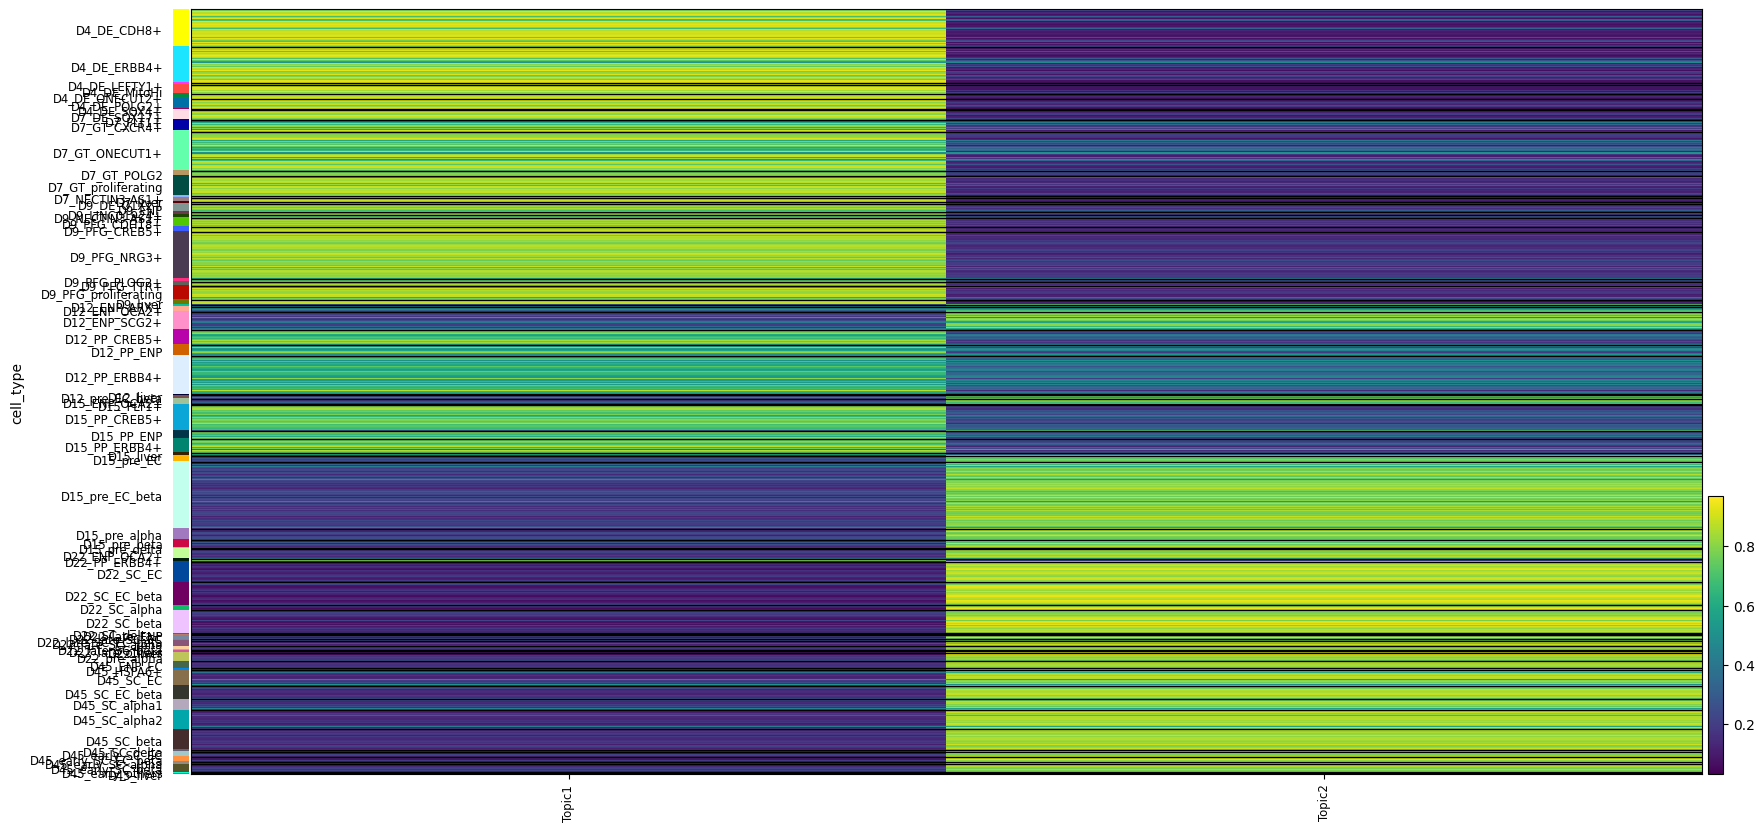

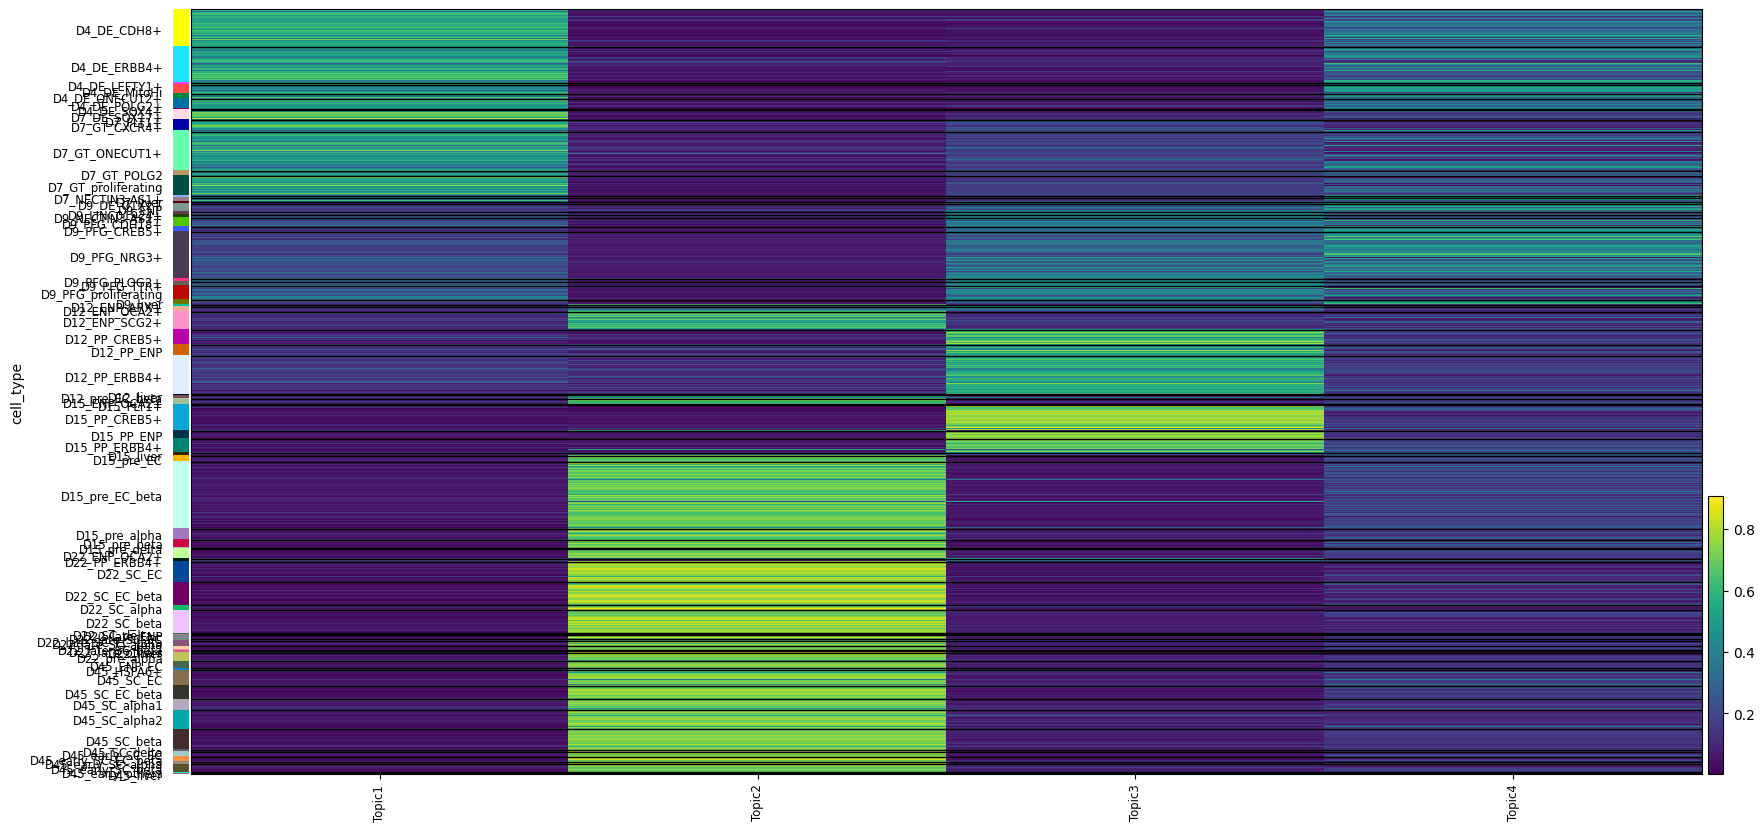

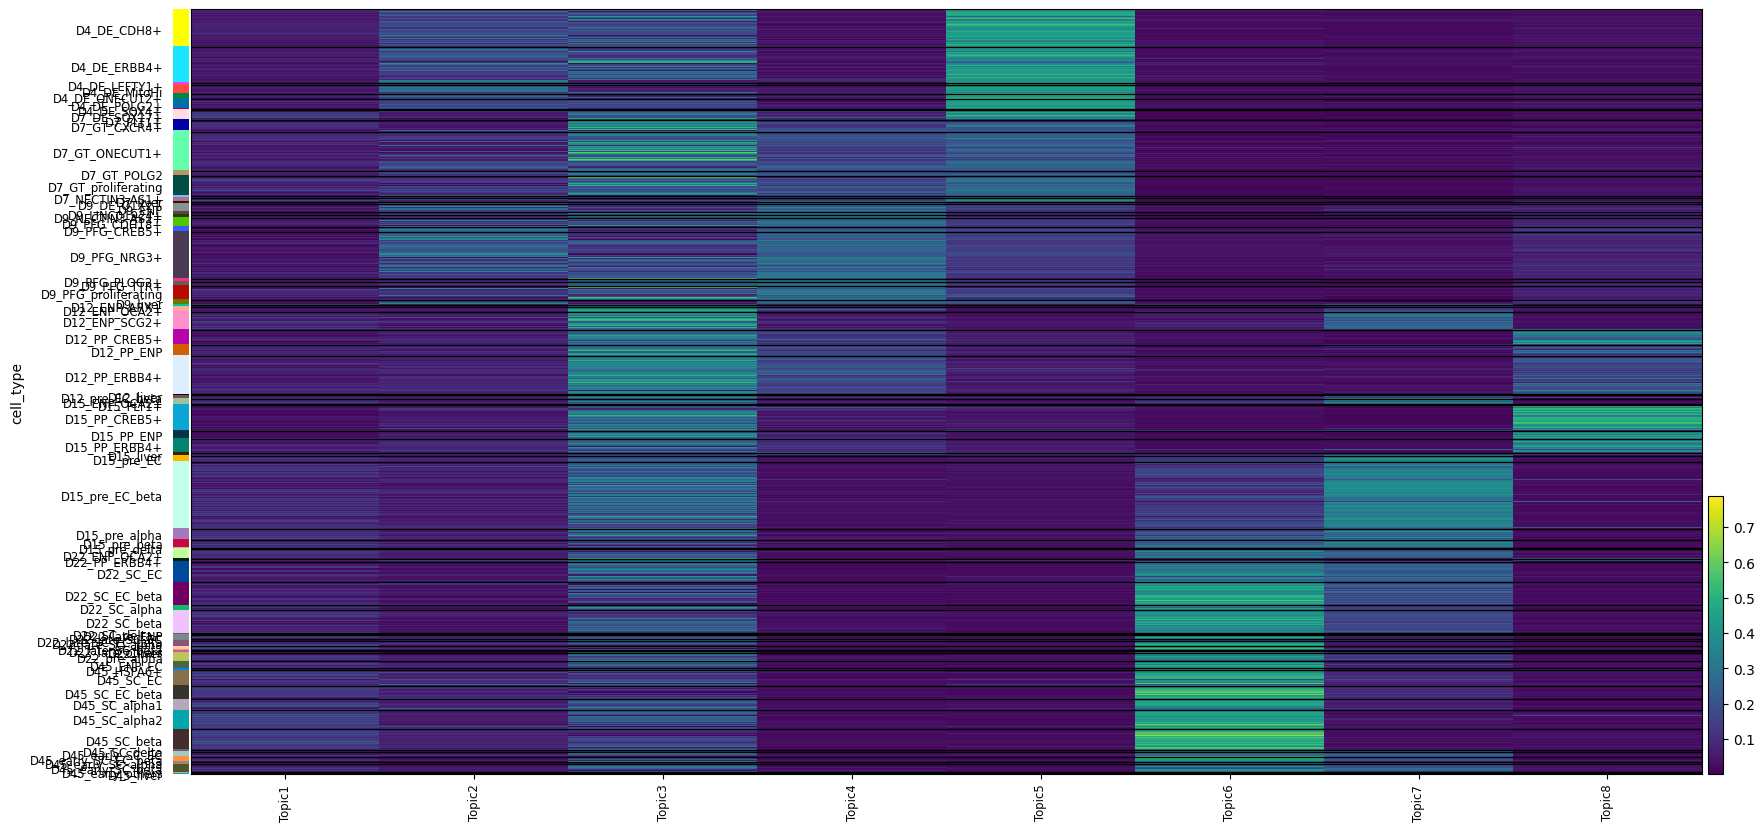

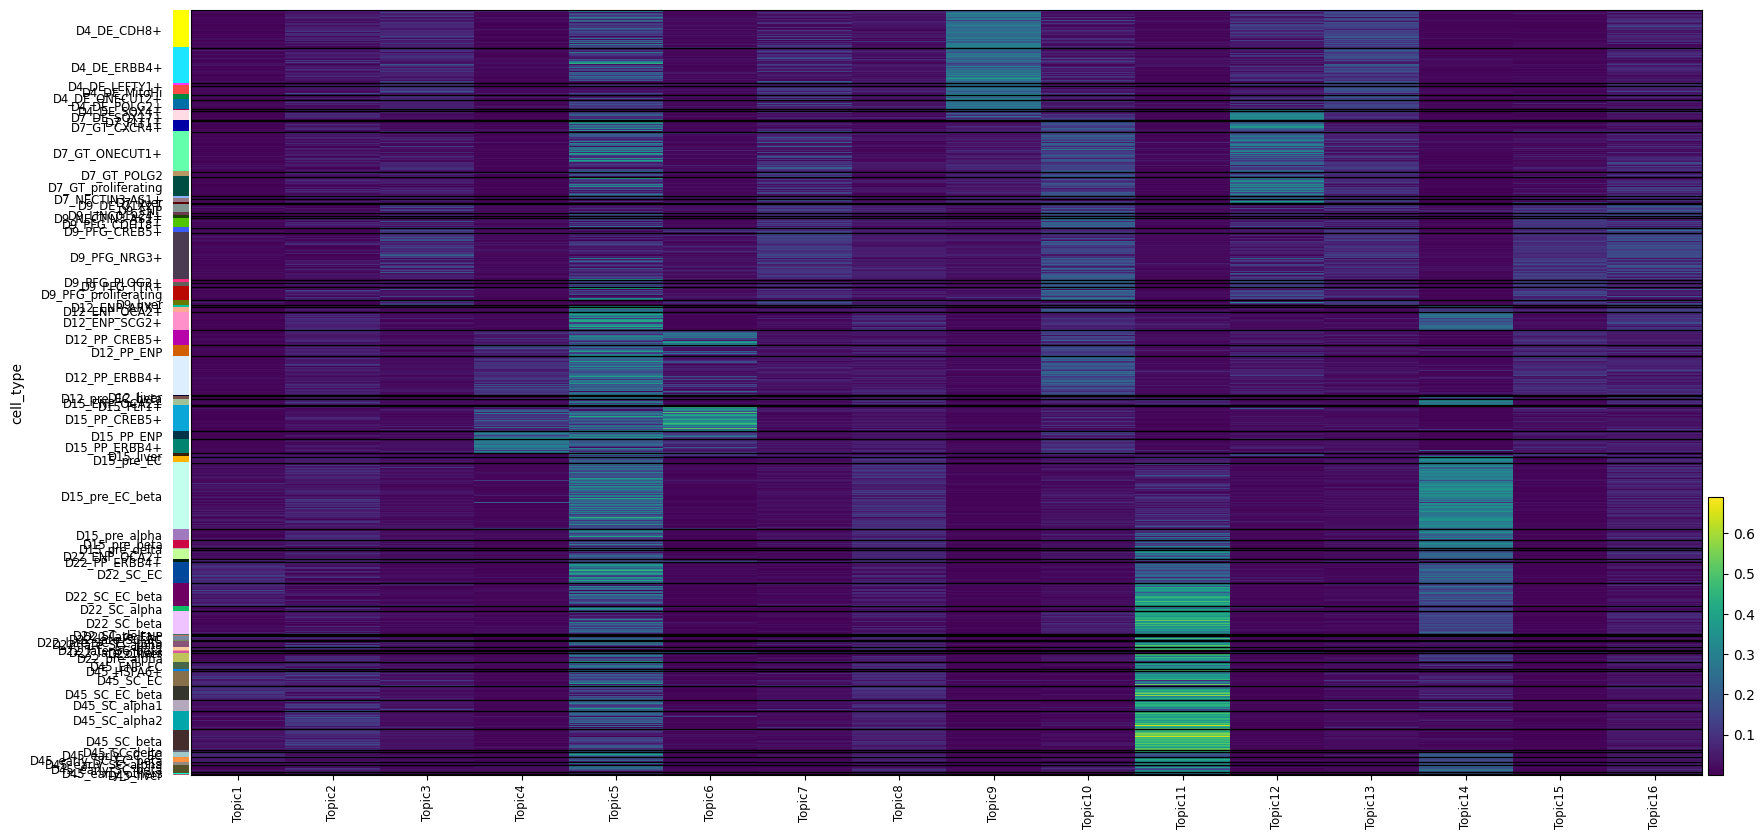

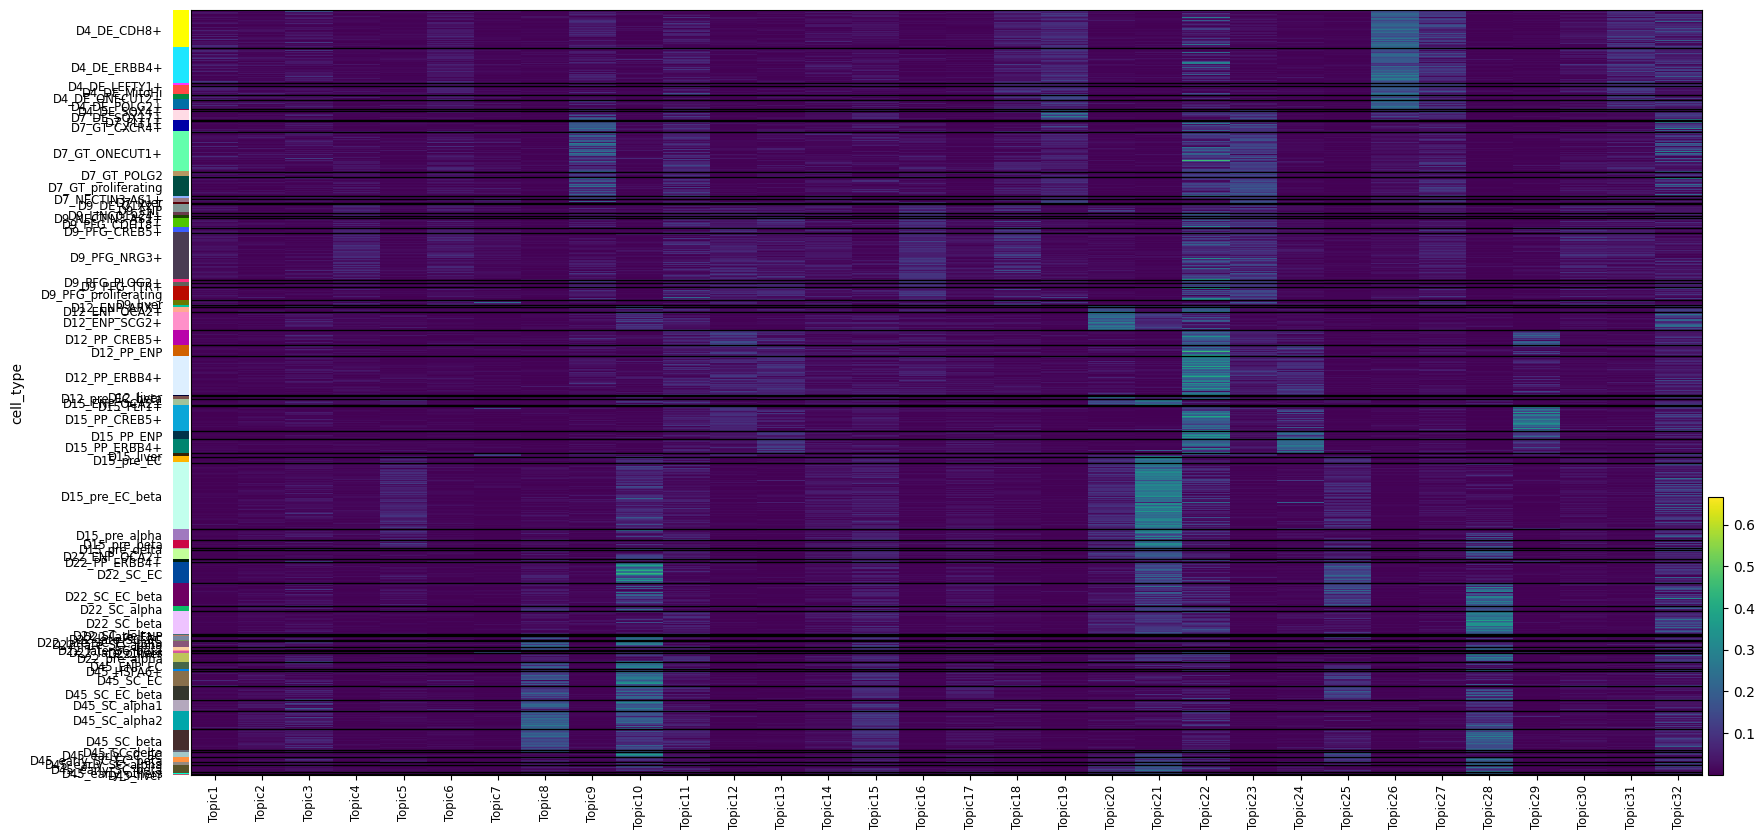

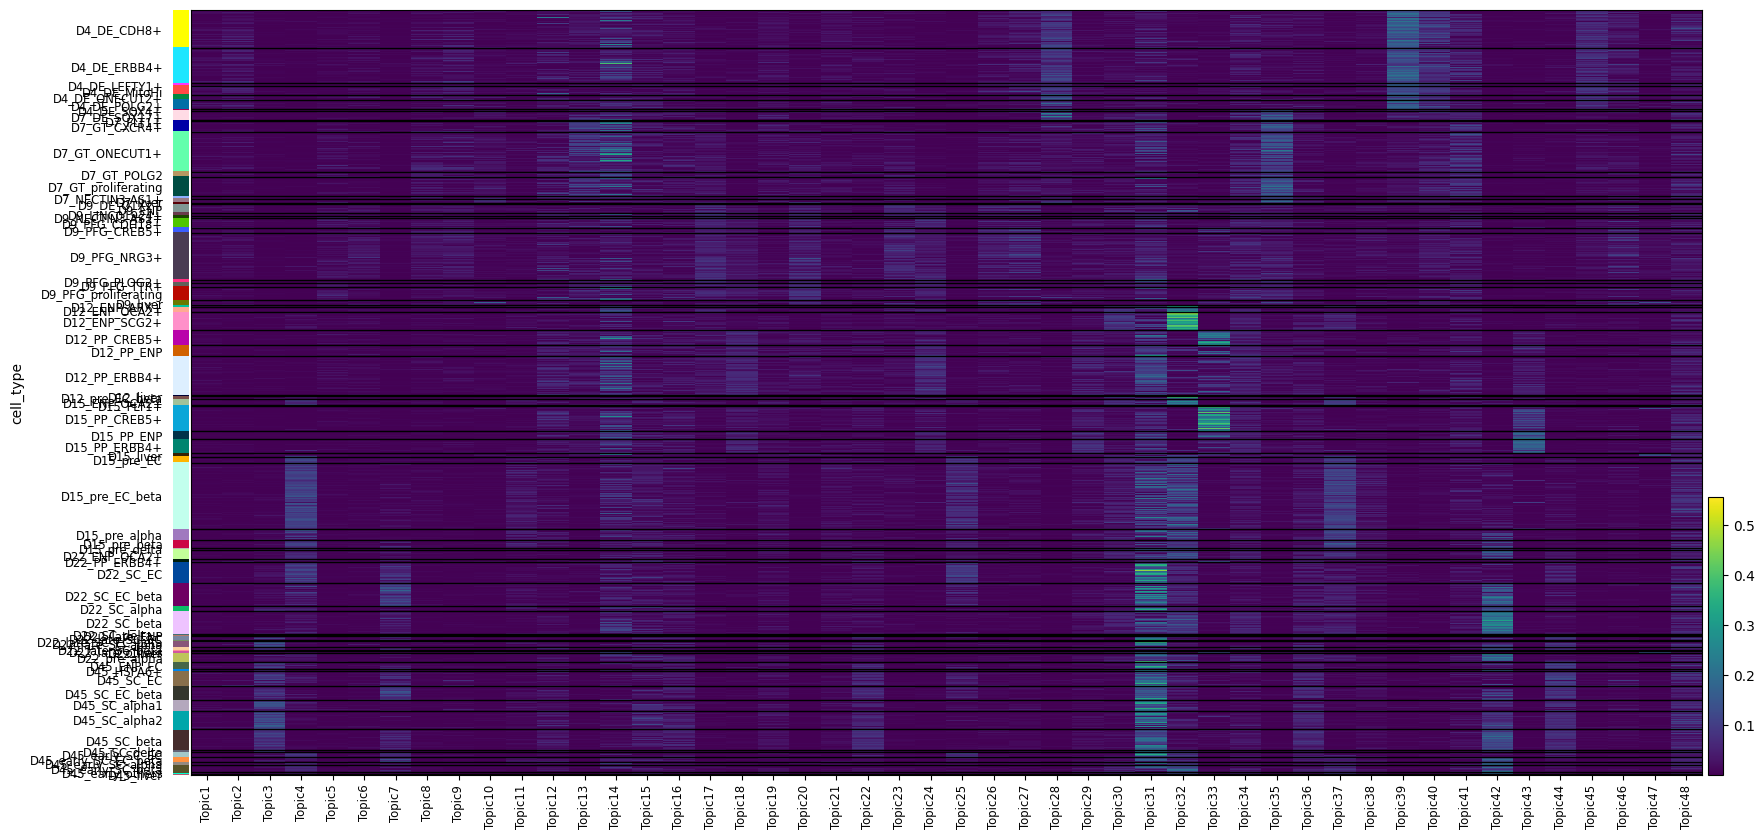

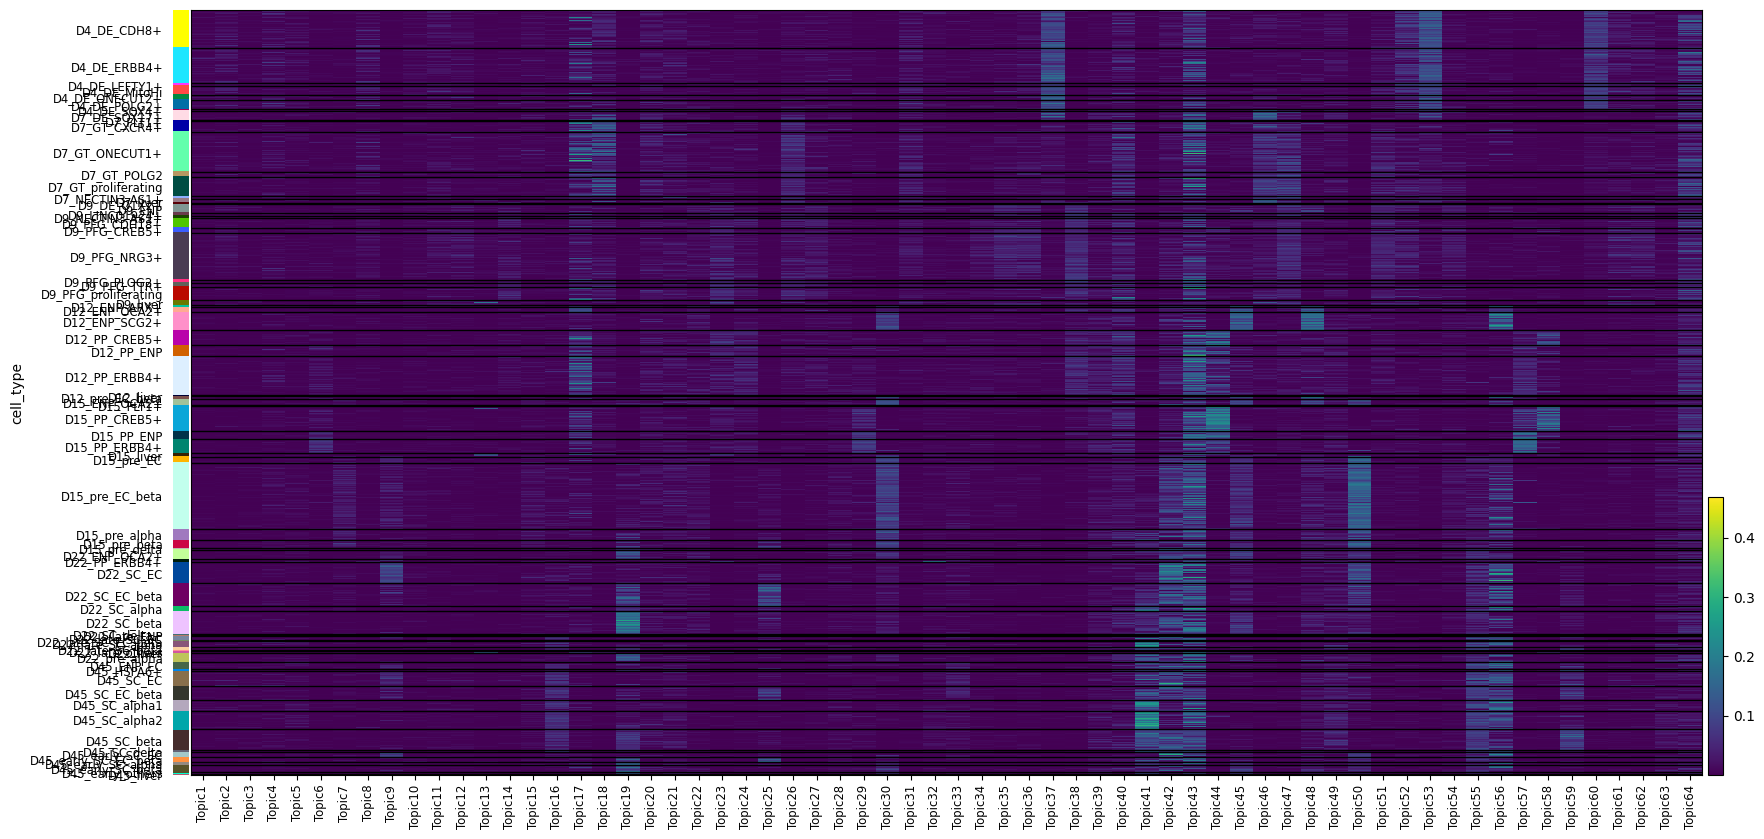

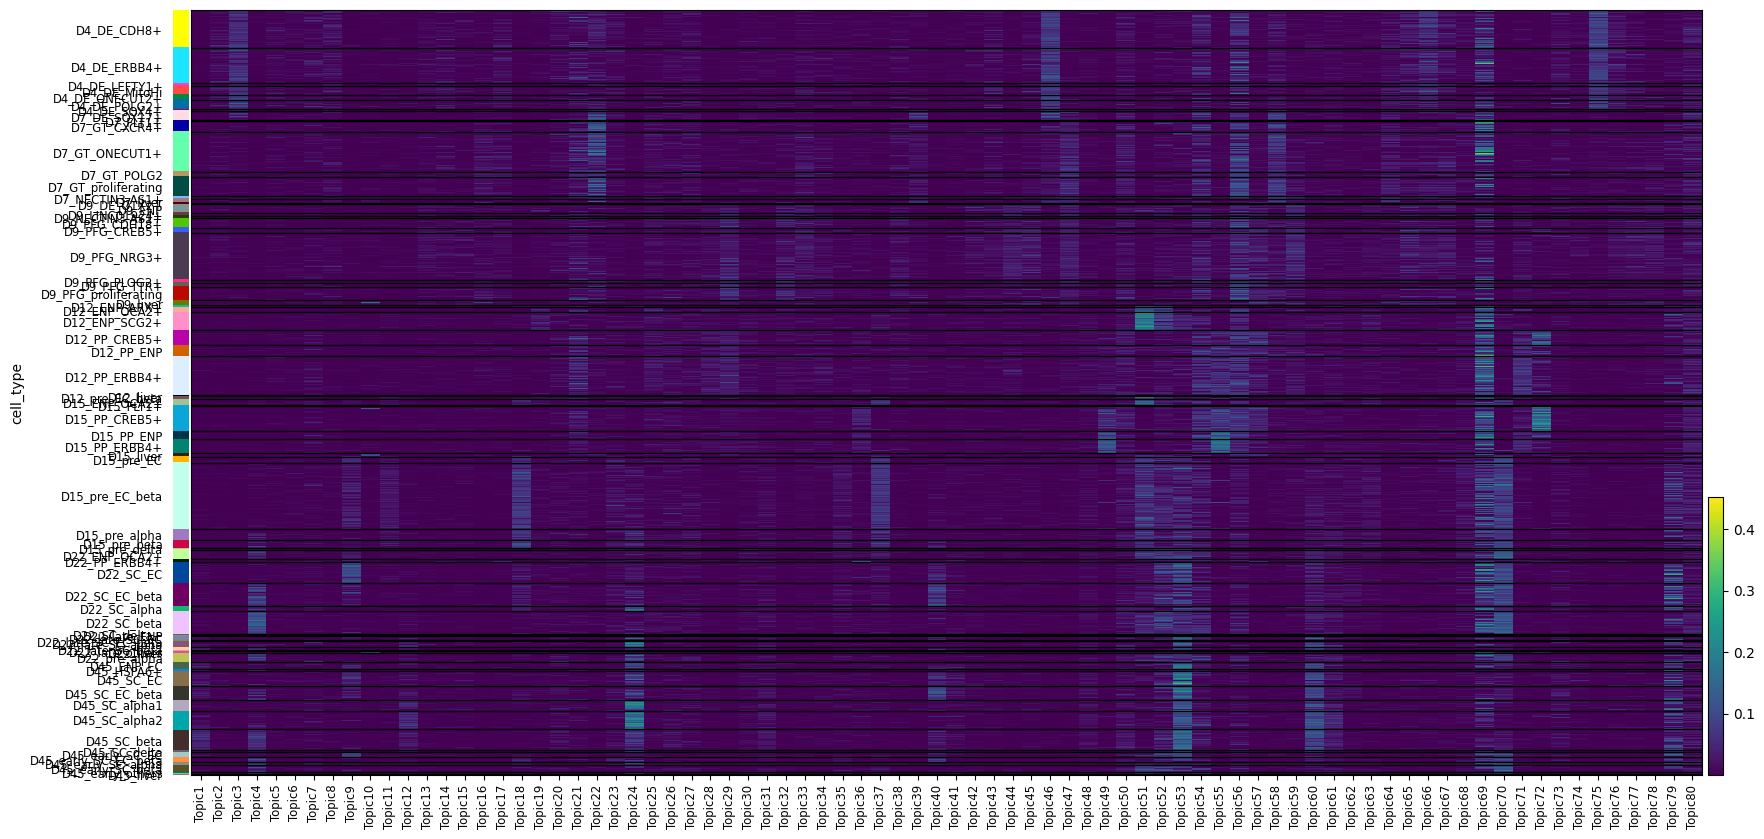

In [17]:
for n_topic in [2, 4, 8, 16, 32, 48, 64, 80]:
    print(f"Running {n_topic} topics")

    # Grab the model
    model = evaluate_models(
        models,
        select_model=n_topic,
        return_model=True,
        metrics=['Arun_2010','Cao_Juan_2009', 'Minmo_2011', 'loglikelihood'],
        plot_metrics=False,
        plot=False
    )
    cistopic_obj.add_LDA_model(model)

    # Add the cell topic matrix to adata
    cell_topic_df = cistopic_obj.selected_model.cell_topic.copy()
    cell_topic_df.columns = cell_topic_df.columns.str.split("___", expand=True).get_level_values(0)
    cell_topic_df = cell_topic_df[adata.obs_names]
    adata.obsm[f"X_cisTopic_{n_topic}_topics"] = cell_topic_df.values.T
    
    # Run cisTopic UMAP and add to adata
    print("Running cisTopic UMAP")
    #run_umap(cistopic_obj, target  = 'cell', scale=False)
    #umap_dims = cistopic_obj.projections["cell"]["UMAP"].copy()
    #umap_dims.index = umap_dims.index.str.split("___", expand=True).get_level_values(0)
    #adata.obsm[f"X_cisTopic_umap_{n_topic}_topics"] = umap_dims.loc[adata.obs.index].values
    
    # Run scanpy UMAP and add to adata
    print("Running scanpy UMAP")
    #sc.pp.neighbors(adata, use_rep=f"X_cisTopic_{n_topic}_topics", n_neighbors=30, metric="cosine")
    #sc.tl.umap(adata, min_dist=0.1, spread=5, random_state=1234)
    #adata.obsm[f"X_scanpy_umap_{n_topic}_topics"] = adata.obsm["X_umap"].copy()

    # Make an anndata where features are the topics
    adata_topics = ad.AnnData(
        X=cell_topic_df.values.copy().T,
        obs=adata.obs.copy(),
        var=pd.DataFrame(index=cell_topic_df.index)
    )

    ax = sc.pl.heatmap(
        adata_topics,
        var_names=adata_topics.var_names,
        groupby=groupby_key,
        use_raw=False,
        log=False,
        figsize=(20, 10),
        cmap="viridis",
        show=False,
        show_gene_labels=True,
    )    

... storing 'sample_id' as categorical


Plotting 2 topics


/cellar/users/aklie/opt/miniconda3/envs/test_scenicplus_dev/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:378: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/cellar/users/aklie/opt/miniconda3/envs/test_scenicplus_dev/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:378: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Plotting 4 topics


/cellar/users/aklie/opt/miniconda3/envs/test_scenicplus_dev/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:378: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/cellar/users/aklie/opt/miniconda3/envs/test_scenicplus_dev/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:378: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


...

/cellar/users/aklie/opt/miniconda3/envs/test_scenicplus_dev/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:378: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/cellar/users/aklie/opt/miniconda3/envs/test_scenicplus_dev/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:378: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Plotting 64 topics


/cellar/users/aklie/opt/miniconda3/envs/test_scenicplus_dev/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:378: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/cellar/users/aklie/opt/miniconda3/envs/test_scenicplus_dev/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:378: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Plotting 80 topics


/cellar/users/aklie/opt/miniconda3/envs/test_scenicplus_dev/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:378: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/cellar/users/aklie/opt/miniconda3/envs/test_scenicplus_dev/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:378: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


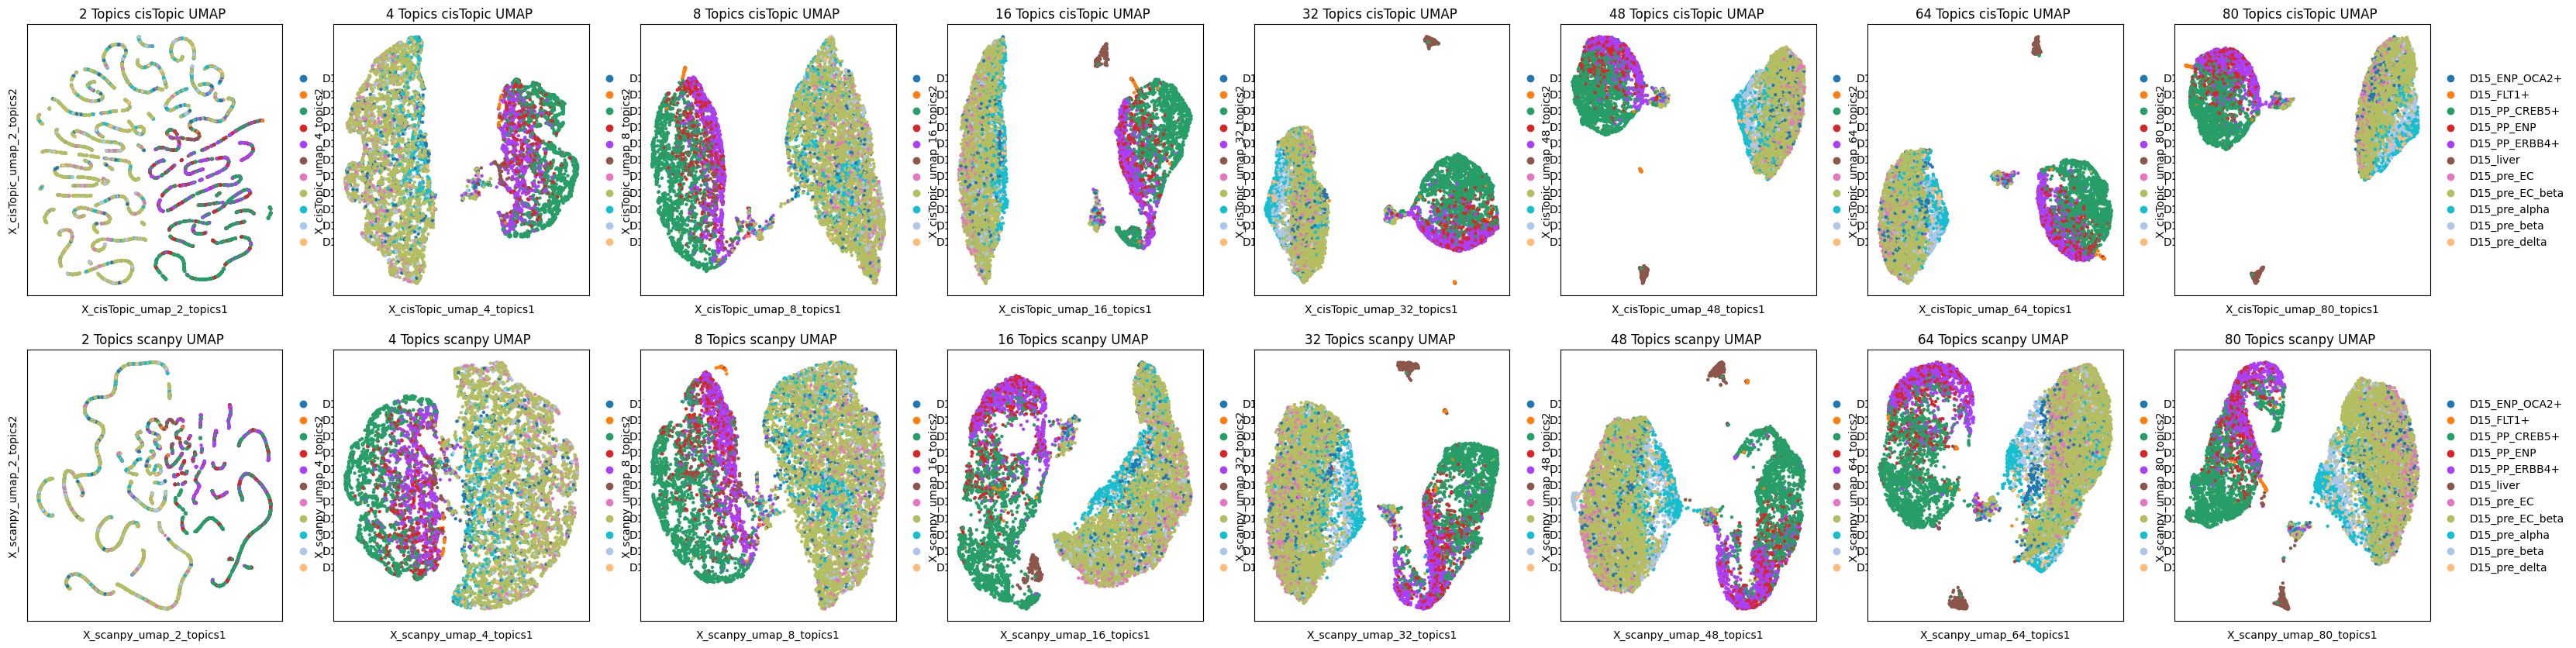

In [ ]:
fig, ax = plt.subplots(2, 8, figsize=(40, 10))
metadata = groupby_key
for i, n_topic in enumerate([2, 4, 8, 16, 32, 48, 64, 80]):
    print(f"Plotting {n_topic} topics")
    sc.pl.embedding(adata, basis=f"X_cisTopic_umap_{n_topic}_topics", color=[metadata], s=40, wspace=0.2, ncols=2, show=False, ax=ax[0][i])
    ax[0][i].set_title(f"{n_topic} Topics cisTopic UMAP ")
    sc.pl.embedding(adata, basis=f"X_scanpy_umap_{n_topic}_topics", color=[metadata], s=40, wspace=0.2, ncols=2, show=False, ax=ax[1][i])
    ax[1][i].set_title(f"{n_topic} Topics scanpy UMAP ")

In [ ]:
sc.pl.embedding(adata, basis="X_cisTopic_umap_32_topics", color=categorical_covariates, s=40, wspace=0.2, ncols=2)

/cellar/users/aklie/opt/miniconda3/envs/test_scenicplus_dev/lib/python3.11/site-packages/anndata/_core/anndata.py:1301: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


: 

: 

: 

# Choose one model

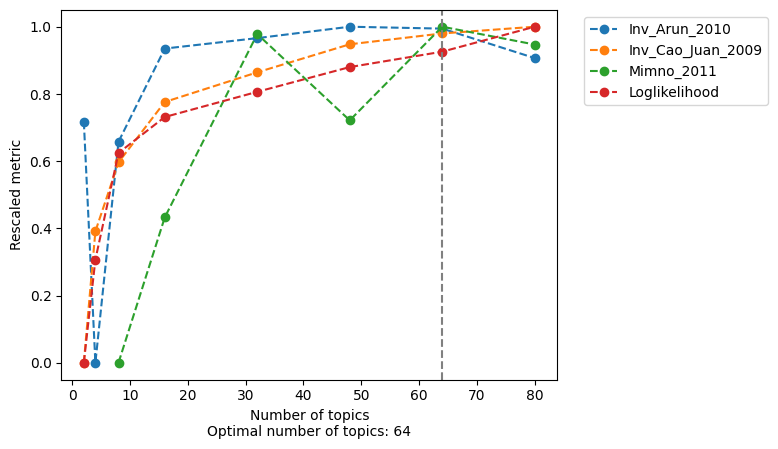

In [18]:
# Grab the model
model = evaluate_models(
    models,
    select_model=64,
    return_model=True,
    metrics=['Arun_2010','Cao_Juan_2009', 'Minmo_2011', 'loglikelihood'],
    plot_metrics=False,
)
cistopic_obj.add_LDA_model(model)

In [19]:
# Add the cell topic matrix to adata
cell_topic_df = cistopic_obj.selected_model.cell_topic.copy()
cell_topic_df.columns = cell_topic_df.columns.str.split("___", expand=True).get_level_values(0)
cell_topic_df = cell_topic_df[adata.obs_names]
cell_topic_df.head()

,D7_GT_POLG2#AAACCGCGTCATCATC-1,D7_GT_POLG2#AAACGCGCAGGCCATT-1,D7_GT_POLG2#AAACGGATCCCGAAGC-1,D7_GT_POLG2#AAAGCACCACATTGCA-1,D7_GT_POLG2#AAAGCCCGTTAGGCGT-1,D7_GT_POLG2#AAAGCCGCAACTAGCC-1,D7_GT_POLG2#AAAGCTTGTTGTTGCT-1,D7_GT_POLG2#AAAGGTTAGACTAAGG-1,D7_GT_POLG2#AAATCCGGTTGGTTAG-1,D7_GT_POLG2#AACAGATAGAGGGACT-1,...,D4_DE_ERBB4+#TTTGTCTAGTTGTCAA-1,D4_DE_ERBB4+#TTTGTGAAGCTGAGGG-1,D4_DE_ERBB4+#TTTGTGAAGTTAGGCT-1,D4_DE_ERBB4+#TTTGTGGCACCATATG-1,D4_DE_ERBB4+#TTTGTGTTCAGCTAAC-1,D4_DE_ERBB4+#TTTGTGTTCATTACAG-1,D4_DE_ERBB4+#TTTGTGTTCTGGTCCT-1,D4_DE_ERBB4+#TTTGTTGGTAATTAGC-1,D4_DE_ERBB4+#TTTGTTGGTCCTAGTT-1,D4_DE_ERBB4+#TTTGTTGGTTGCAATG-1
Topic1,0.000118,0.000356,0.000432,0.002723,0.000805,0.006819,0.000621,0.006045,0.000887,0.002415,...,0.003176,0.005675,0.003050,0.009528,0.004948,0.001860,0.016293,0.001728,0.023513,0.009469
Topic2,0.002899,0.002402,0.000071,0.003862,0.000229,0.005234,0.005459,0.000376,0.000285,0.003030,...,0.031293,0.000283,0.003050,0.019192,0.016059,0.000665,0.026796,0.003941,0.016301,0.018978
Topic3,0.005216,0.000739,0.000071,0.001584,0.001381,0.009653,0.009491,0.000376,0.008339,0.000570,...,0.014239,0.000600,0.003050,0.001531,0.004948,0.020029,0.000537,0.003941,0.001878,0.000332
Topic4,0.001906,0.023501,0.000161,0.005001,0.000064,0.002316,0.007763,0.006244,0.000209,0.000160,...,0.000180,0.005199,0.020173,0.018192,0.032726,0.005924,0.013880,0.090224,0.028320,0.024759
Topic5,0.003362,0.008156,0.003231,0.002153,0.001134,0.009737,0.013235,0.000177,0.009017,0.007539,...,0.005711,0.008371,0.011612,0.007084,0.002170,0.001143,0.004085,0.019428,0.006686,0.004061


In [20]:
# Make an anndata where features are the topics
adata_topics = ad.AnnData(
    X=cell_topic_df.values.copy().T,
    obs=adata.obs.copy(),
    var=pd.DataFrame(index=cell_topic_df.index)
)
adata_topics.obsm["X_cisTopic"] = cell_topic_df.values.T

In [21]:
# Run cisTopic UMAP
run_umap(cistopic_obj, target='cell', scale=False)

2025-12-15 09:18:49,769 cisTopic     INFO     Running UMAP


/cellar/users/aklie/opt/miniconda3/envs/test_scenicplus_dev/lib/python3.11/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


In [22]:
# Add to adata
umap_dims = cistopic_obj.projections["cell"]["UMAP"].copy()
umap_dims.index = umap_dims.index.str.split("___", expand=True).get_level_values(0)
adata_topics.obsm[f"X_umap"] = umap_dims.loc[adata_topics.obs.index].values

... storing 'cell_type' as categorical
... storing 'sample_id' as categorical
... storing 'day' as categorical
... storing 'stage' as categorical
... storing 'marker' as categorical
... storing 'grouping' as categorical
/cellar/users/aklie/opt/miniconda3/envs/test_scenicplus_dev/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:378: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


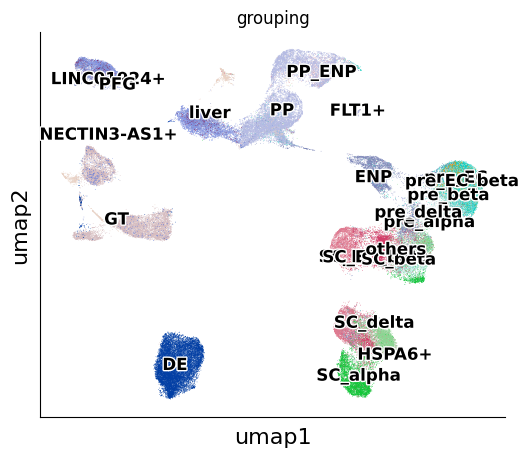

In [23]:
pretty_umap(
    adata_topics,
    color_key="grouping",
    s=1
)

/cellar/users/aklie/opt/miniconda3/envs/test_scenicplus_dev/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:378: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/cellar/users/aklie/opt/miniconda3/envs/test_scenicplus_dev/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:378: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/cellar/users/aklie/opt/miniconda3/envs/test_scenicplus_dev/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:378: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


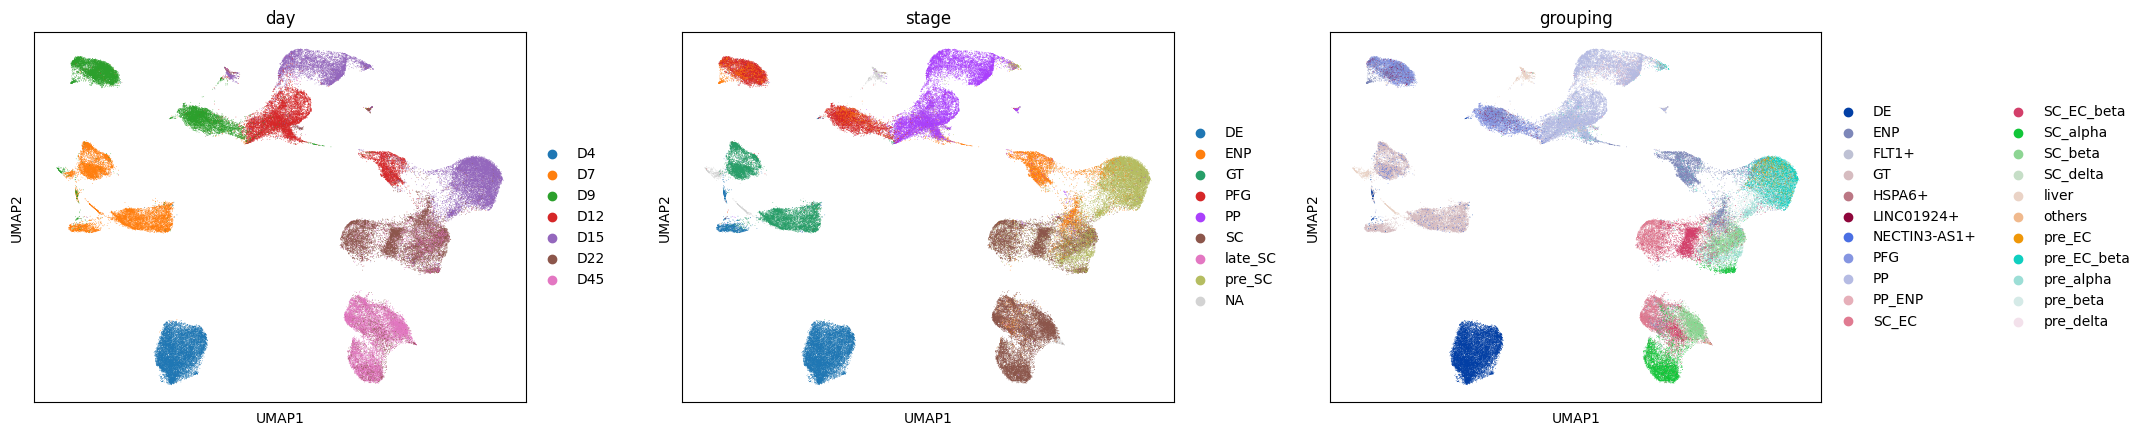

In [81]:
# Plot UMAP
sc.pl.umap(adata_topics, color=["day", "stage", "grouping"], s=1, wspace=0.2, ncols=3)

In [24]:
# Add scaled data layer
adata_topics.layers["scaled"] = sc.pp.scale(adata_topics, copy=True).X

/cellar/users/aklie/opt/miniconda3/envs/test_scenicplus_dev/lib/python3.11/site-packages/scanpy/plotting/_anndata.py:2406: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
  obs_tidy.index.value_counts(sort=False).iteritems()


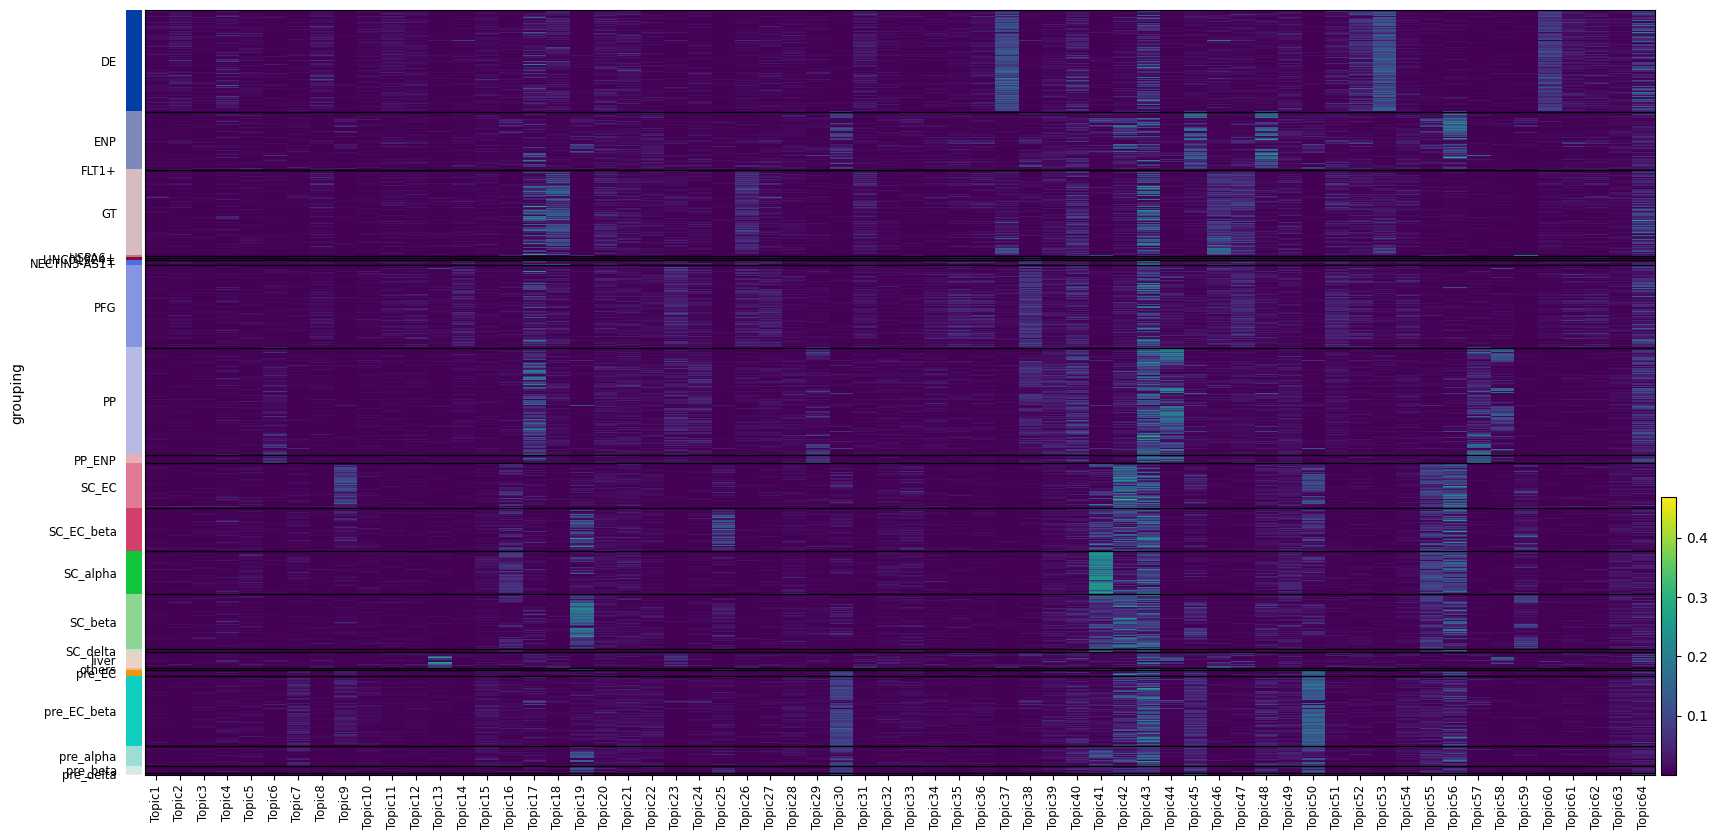

In [25]:
# Plot as heatmap
ax = sc.pl.heatmap(
    adata_topics,
    var_names=adata_topics.var_names,
    groupby="grouping",
    use_raw=False,
    log=False,
    figsize=(20, 10),
    cmap="viridis",
    #layer="scaled",
    show=False,
    show_gene_labels=True,
    #vmin=-2,
    #vmax=4,
)

In [26]:
sc.tl.rank_genes_groups(adata_topics, groupby="grouping", method="wilcoxon", n_genes=10)

/cellar/users/aklie/opt/miniconda3/envs/test_scenicplus_dev/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:394: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, 'names'] = self.var_names[global_indices]
/cellar/users/aklie/opt/miniconda3/envs/test_scenicplus_dev/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:396: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, 'scores'] = scores[global_indices]
/cellar/users/aklie/opt/miniconda3/envs/test_scenicplus_dev/l

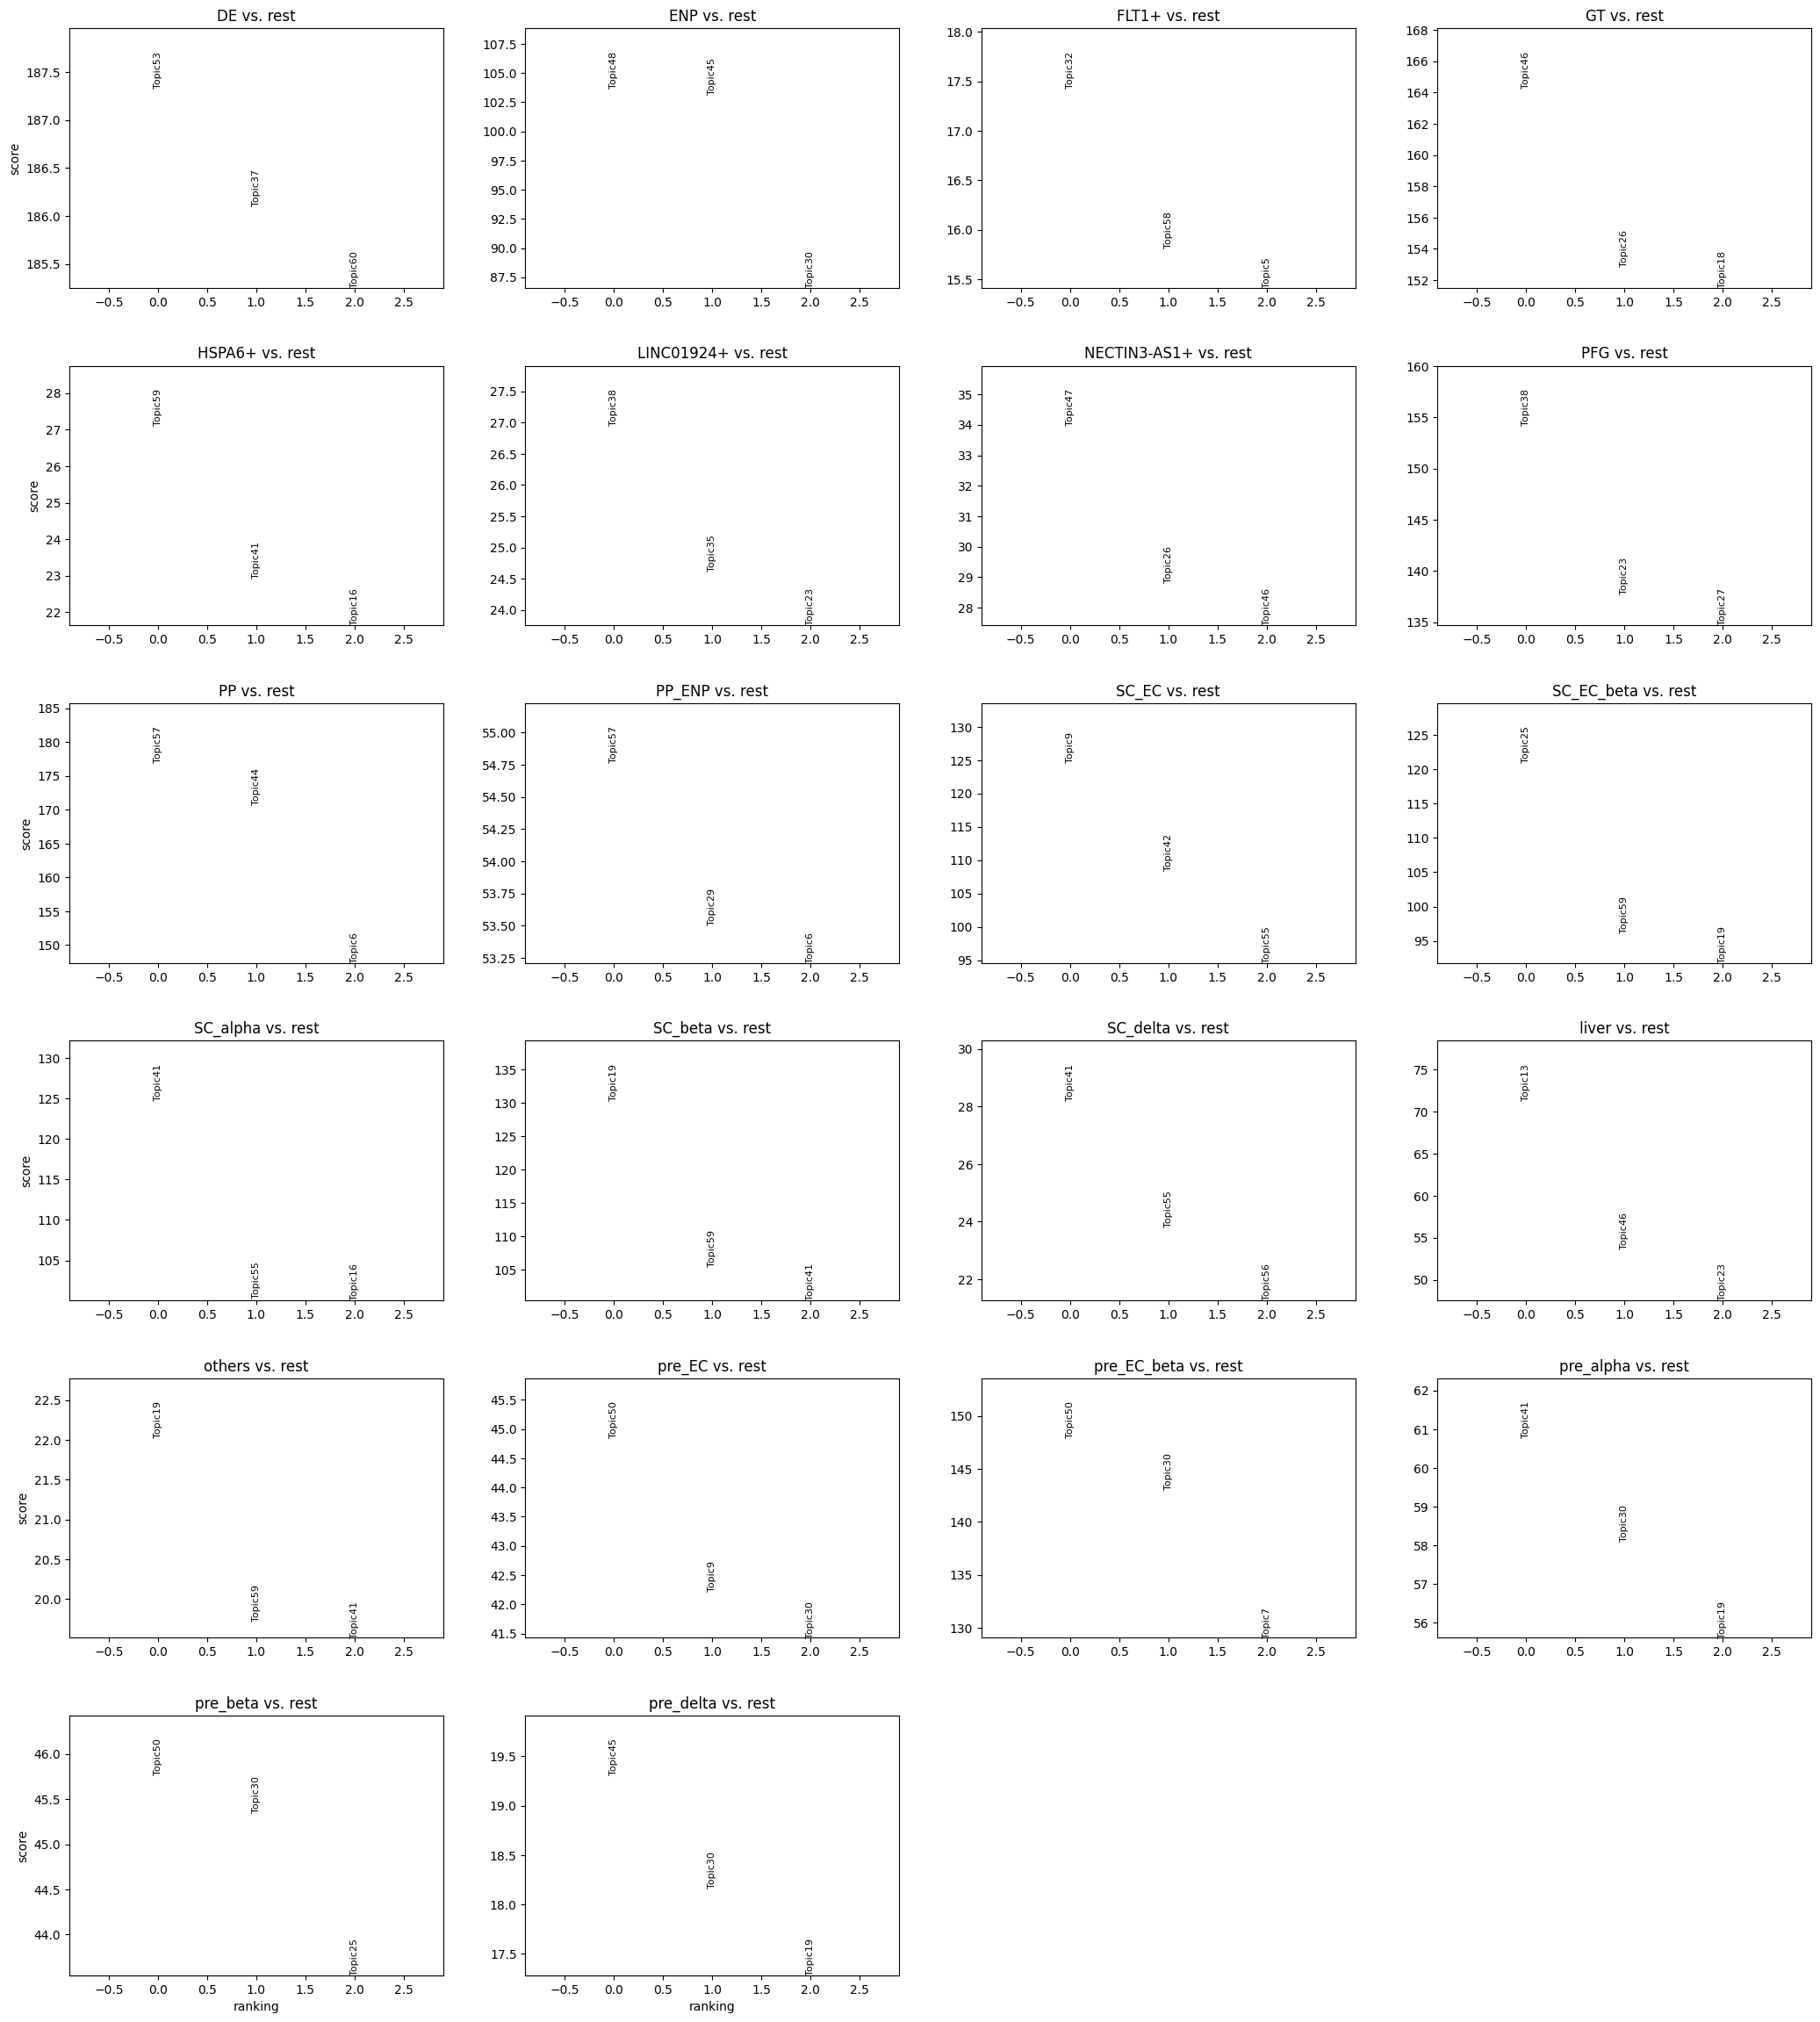

In [27]:
sc.pl.rank_genes_groups(adata_topics, n_genes=3, sharey=False)

         Falling back to preprocessing with `sc.pp.pca` and default params.


/cellar/users/aklie/opt/miniconda3/envs/test_scenicplus_dev/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/cellar/users/aklie/opt/miniconda3/envs/test_scenicplus_dev/lib/python3.11/site-packages/scanpy/plotting/_anndata.py:2406: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
  obs_tidy.index.value_counts(sort=False).iteritems()


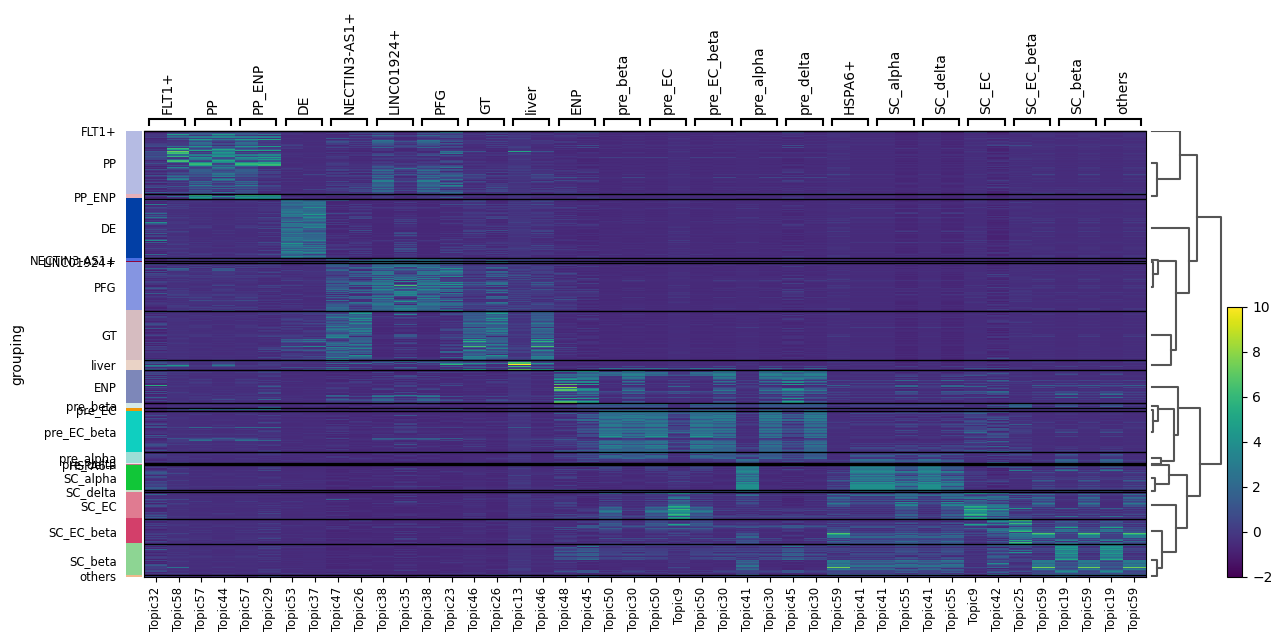

In [28]:
sc.pl.rank_genes_groups_heatmap(adata_topics, groupby="grouping", n_genes=2, use_raw=False, log=False, show_gene_labels=True, layer="scaled", cmap="viridis", vmin=-2, vmax=10)

In [29]:
# Get dictionary of top 2 marker genes for each annotation
marker_topics = {}
for annotation in adata_topics.obs["grouping"].unique():
    marker_genes = adata_topics.uns["rank_genes_groups"]["names"][annotation]
    marker_topics[annotation] = marker_genes[:3]
marker_topics

order = adata_topics.obs["grouping"].value_counts().index.tolist()
marker_topics = {k: v for k, v in marker_topics.items() if k in order}

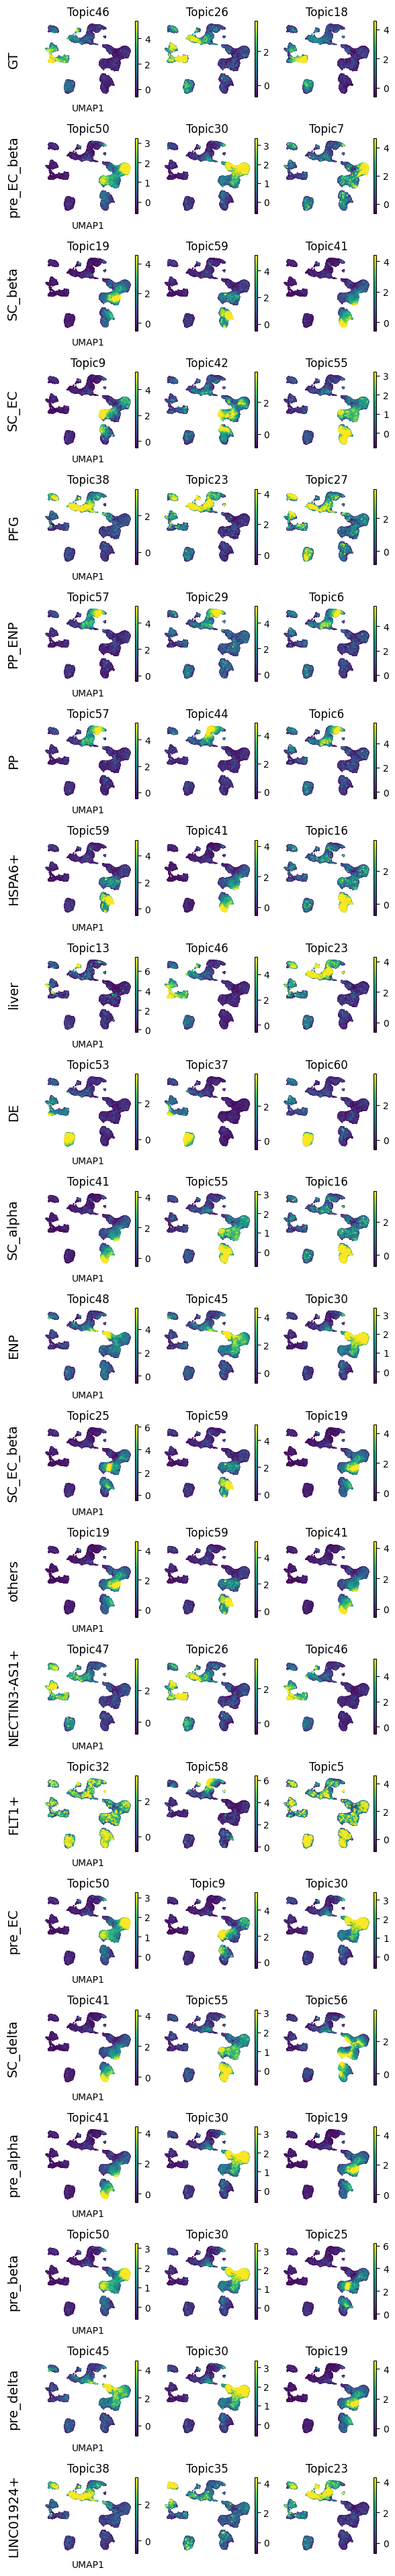

In [30]:
nrow = len(marker_topics)
ncol = max([len(vs) for vs in marker_topics.values()])
fig, axs = plt.subplots(nrow, ncol, figsize=(2 * ncol, 1.75 * nrow))
for row_idx, (annotation, markers) in enumerate(marker_topics.items()):
    col_idx = 0
    for marker in markers:
        ax = axs[row_idx, col_idx]
        sc.pl.umap(adata_topics, color=marker, ax=ax, show=False, frameon=False, s=10, vmin="p5", vmax="p99.5", layer="scaled")
        if col_idx == 0:
            # We disabled axis drawing in UMAP to have plots without background and border
            # so we need to re-enable axis to plot the ylabel
            ax.axis("on")
            ax.tick_params(
                top="off",
                bottom="off",
                left="off",
                right="off",
                labelleft="on",
                labelbottom="off",
            )
            ax.set_ylabel(annotation + "\n", rotation=90, fontsize=14)
            ax.set(frame_on=False)
        col_idx += 1
    # Remove unused column Axes in the current row
    while col_idx < ncol:
        axs[row_idx, col_idx].remove()
        col_idx += 1
        
# Alignment within the Figure
fig.tight_layout()

## Unsupervised clustering to identify substructure

In [ ]:
sc.pp.neighbors(adata_topics, use_rep="X_cisTopic", n_neighbors=30, metric="cosine")

In [ ]:
sc.tl.leiden(adata_topics, resolution=0.2, key_added="leiden_0.2_32_topics")
sc.tl.leiden(adata_topics, resolution=0.5, key_added="leiden_0.5_32_topics")
sc.tl.leiden(adata_topics, resolution=0.8, key_added="leiden_0.8_32_topics")
sc.tl.leiden(adata_topics, resolution=1.0, key_added="leiden_1.0_32_topics")
sc.tl.leiden(adata_topics, resolution=1.5, key_added="leiden_1.5_32_topics")

/cellar/users/aklie/opt/miniconda3/envs/test_scenicplus/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/cellar/users/aklie/opt/miniconda3/envs/test_scenicplus/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/cellar/users/aklie/opt/miniconda3/envs/test_scenicplus/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/cellar/users/aklie/opt/miniconda3/envs/test_scenicplus/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/cellar/users/aklie/opt/miniconda3/envs/test_scenicplus/

[<AxesSubplot: title={'center': 'leiden_0.2'}, xlabel='UMAP1', ylabel='UMAP2'>,
 <AxesSubplot: title={'center': 'leiden_0.5'}, xlabel='UMAP1', ylabel='UMAP2'>,
 <AxesSubplot: title={'center': 'leiden_0.8'}, xlabel='UMAP1', ylabel='UMAP2'>,
 <AxesSubplot: title={'center': 'leiden_1'}, xlabel='UMAP1', ylabel='UMAP2'>,
 <AxesSubplot: title={'center': 'leiden_1.5'}, xlabel='UMAP1', ylabel='UMAP2'>,
 <AxesSubplot: title={'center': 'annotation'}, xlabel='UMAP1', ylabel='UMAP2'>]

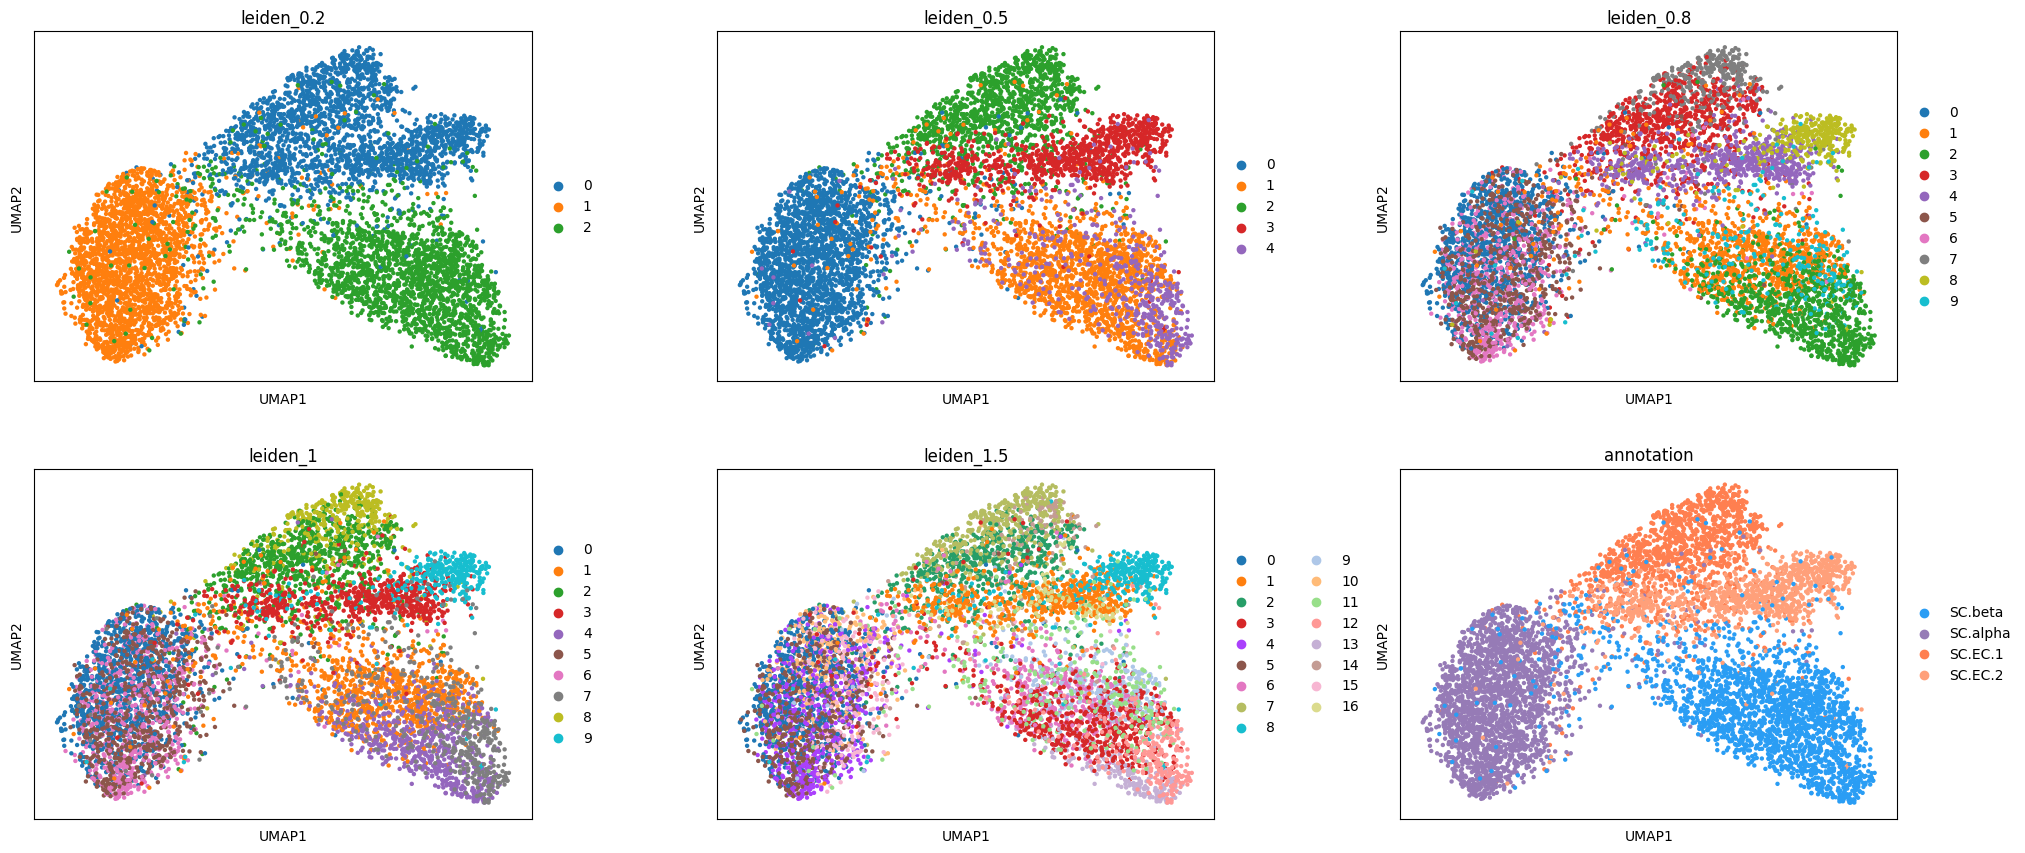

In [ ]:
# Check different clustering res
sc.pl.umap(adata_topics, color=["leiden_0.2", "leiden_0.5", "leiden_0.8", "leiden_1", "leiden_1.5", "annotation"], ncols=3, s=40, wspace=0.25, show=False)

Text(0.5, 1.0, 'Annotation proportions in leiden_0.5 clusters')

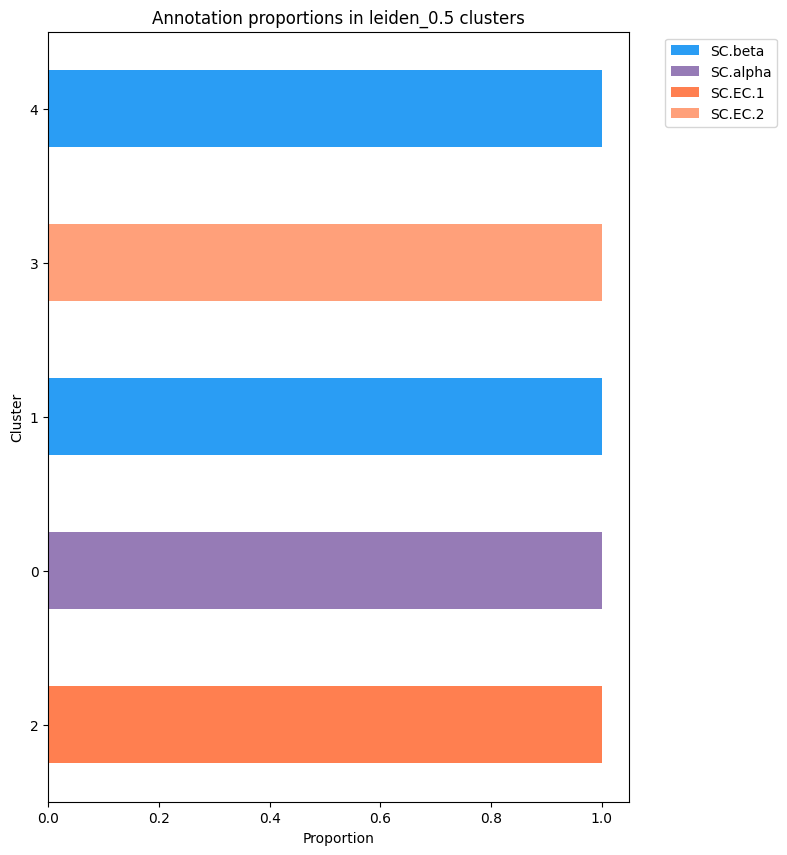

In [392]:
# Stacked barplot of annotation proportions in leiden_0.5 clusters
leiden = adata_topics.obs["leiden_0.5"].unique().tolist()
annotation_proportions = []
for cluster in leiden:
    proportions = adata_topics.obs[adata_topics.obs["leiden_0.5"] == cluster]["annotation"].value_counts(normalize=True)
    proportions.name = cluster
    annotation_proportions.append(proportions)
annotation_proportions = pd.concat(annotation_proportions, axis=1).T
annotation_proportions = annotation_proportions[cellid_colors.keys()]

# Plot horizontal barplot, legend outside to right
fig, ax = plt.subplots(figsize=(7.5, 10))
annotation_proportions.plot.barh(stacked=True, ax=ax, color=cellid_colors.values())
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel("Proportion")
plt.ylabel("Cluster")
plt.title("Annotation proportions in leiden_0.5 clusters")

/cellar/users/aklie/opt/miniconda3/envs/test_scenicplus/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


Text(0.5, 41.972222222222314, 'Topic')

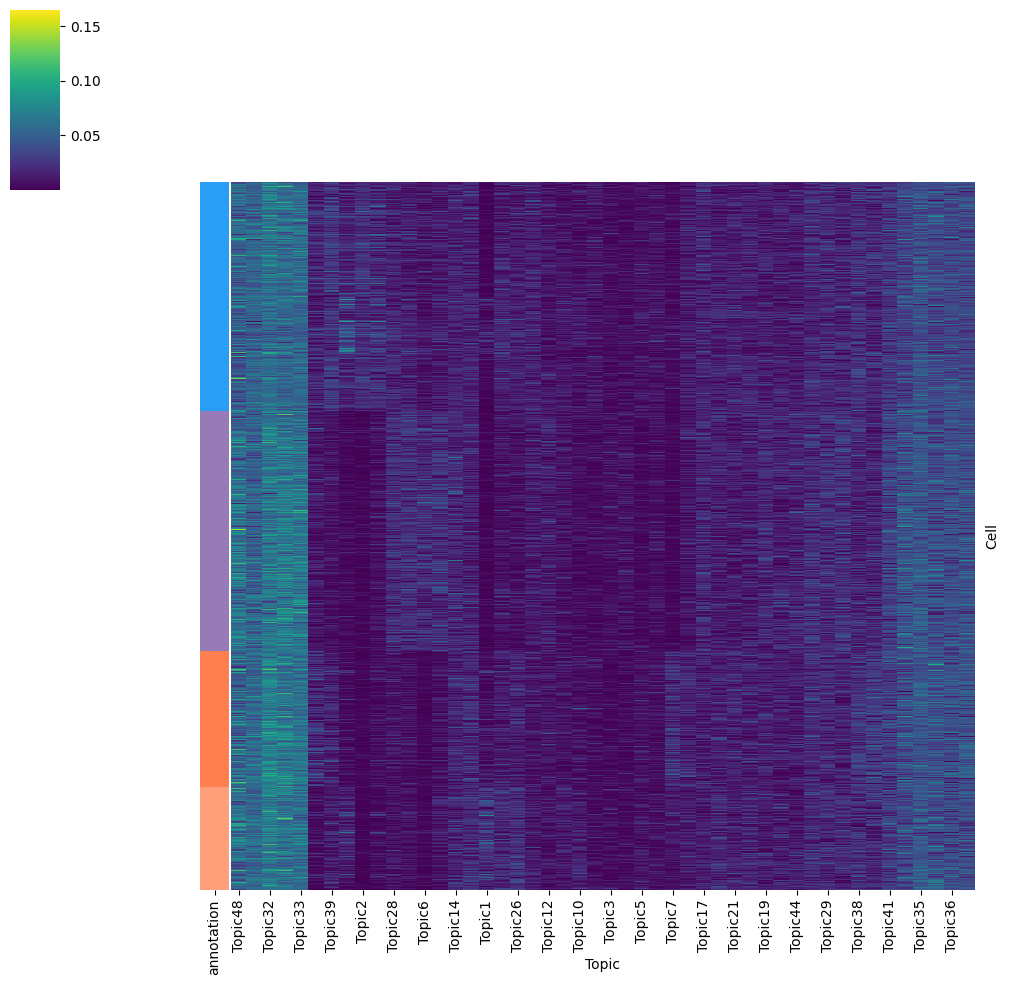

In [393]:
# Clustermap of topics
labels = adata_topics.obs["annotation"]
row_colors = labels.map(cellid_colors)
row_colors.index = adata_topics.obs_names

# Sort the rows by annotation
cell_ordering = adata.obs.sort_values("annotation").index
df = adata_topics.to_df()
df = df.loc[cell_ordering]

ax = sns.clustermap(
    df,
    row_cluster=False,
    col_cluster=True,
    yticklabels=False,
    cmap="viridis",
    row_colors=row_colors,
)

# Add row colors from adata.obs["annotation"]
ax.ax_row_dendrogram.set_visible(False)

ax.ax_col_dendrogram.set_visible(False)
ax.ax_heatmap.set_ylabel("Cell")
ax.ax_heatmap.set_xlabel("Topic")


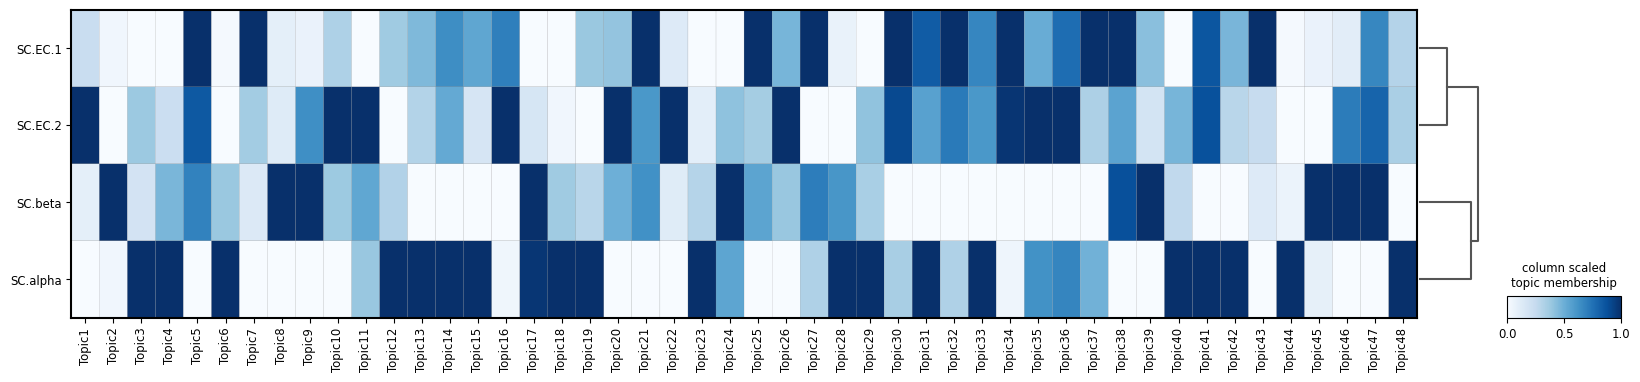

In [394]:
sc.pl.matrixplot(
    adata_topics,
    var_names=adata_topics.var_names,
    groupby="annotation",
    dendrogram=True,
    cmap="Blues",
    standard_scale="var",
    colorbar_title="column scaled\ntopic membership",
    figsize=(20, 4),
)

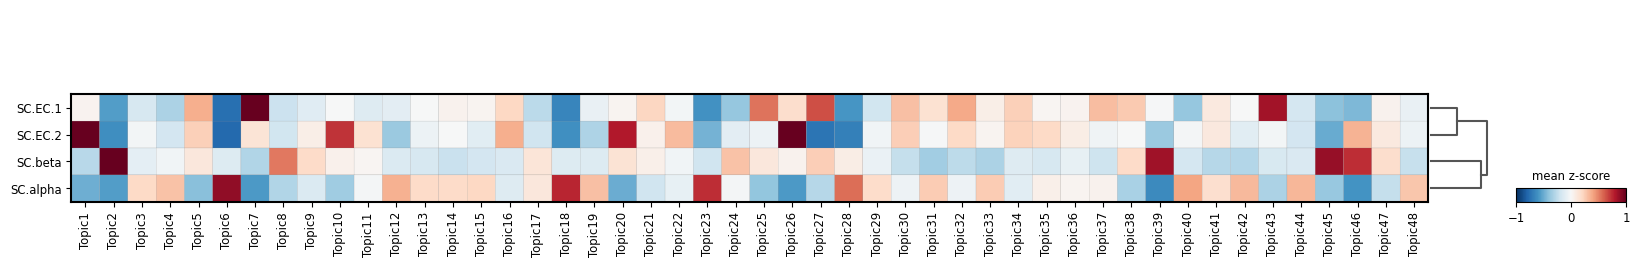

In [395]:
sc.pl.matrixplot(
    adata_topics,
    var_names=adata_topics.var_names,
    groupby="annotation",
    dendrogram=True,
    colorbar_title="mean z-score",
    layer="scaled",
    vmin=-1,
    vmax=1,
    cmap="RdBu_r",
)